<a href="https://colab.research.google.com/github/reubyTuesday/Math509RealEstate/blob/main/USA_Dataset_Ohio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import scipy.stats as stats
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler, StandardScaler #Scaling


from sklearn.decomposition import PCA
# Import the necessary function
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures


Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.11/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['scatter']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


#Just Importing Ohio Set for algorithm Testing


In [2]:
from google.colab import files
uploaded = files.upload()  # This opens a file picker to upload 'subset_dataset.csv'

# Load the subset into a DataFrame
import pandas as pd
df_subset = pd.read_csv('ohio_data.csv')

Saving ohio_data.csv to ohio_data.csv


In [3]:
df_subset.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date,zip_code_encoded,street_encoded
0,102855.0,0,59900.0,1.0,1.0,0.15,644465.0,East Liverpool,Ohio,43920.0,690.0,NaN,129000.0,59900.0
1,21109.0,0,279000.0,5.0,3.0,1.30,1756755.0,East Liverpool,Ohio,43920.0,3010.0,2009-01-08,129000.0,279000.0
2,19178.0,0,75000.0,2.0,2.0,0.17,423802.0,Steubenville,Ohio,43952.0,1080.0,NaN,99900.0,75000.0
3,52584.0,0,498900.0,4.0,4.0,13.52,461131.0,East Liverpool,Ohio,43920.0,2482.0,2015-01-07,129000.0,498900.0
4,53783.0,0,33000.0,3.0,1.0,0.08,1807352.0,East Liverpool,Ohio,43920.0,1518.0,NaN,129000.0,33000.0


## Functions

1. Delete Missing Values



In [4]:
# Function to drop missing values
def drop_missing(grp_col, col_to_check):
    nan_count_before = df[col_to_check].isna().sum()
    df.dropna(subset=[col_to_check], inplace=True)
    nan_count_after = df[col_to_check].isna().sum()

    print(f"Dropped {nan_count_before - nan_count_after} missing values from {col_to_check}.")

# Function to calculate missing values and percentage
## Code from Kaggle: https://www.kaggle.com/code/shaswotj/smart-price-prediction-using-ml
def missing_percentage(data_set):
    total_records = data_set.shape[0]
    missing_counts = data_set.isna().sum()
    missing_percentage = round(missing_counts / total_records * 100, 2)

    missing_summary = pd.DataFrame({
        'Missing Records': missing_counts,
        'Percentage Missing': missing_percentage
    })

    print(f"\nTotal number of records present: {total_records}\n")
    print(missing_summary.sort_values(by='Percentage Missing', ascending=False))
    print("\n")

# Function to imupute missing values with median
def imputer(grp_col,col_to_impute):
    imputer_df = round(df.groupby(grp_col)[col_to_impute].median(),0)
    df['helper_col'] = df[grp_col].map(imputer_df)

    nan_count_before = df[col_to_impute].isna().sum()

    df[col_to_impute] = df[col_to_impute].fillna(df['helper_col'])

    nan_count_after = df[col_to_impute].isna().sum()
    records_affected = nan_count_before - nan_count_after

    df.drop(columns = 'helper_col',inplace = True)
    print(f"Total records imputed for {col_to_impute}: {records_affected}")

In [5]:
# For example, if you have a CSV file named "real_estate.csv":
#df = pd.read_csv('realtor-data.zip.csv') #upload for full data set
df = df_subset.copy() #Just Ohio data

## Drop Missing Values
drop_missing('zip_code','bed')
drop_missing('zip_code','bath')
drop_missing('zip_code','house_size')
drop_missing('zip_code','acre_lot')
drop_missing('zip_code','price')

# Impute missing values of bed, bath, house_size, acre_lot and price using zip_code
# I am not sure exactly how we want to impute these so I am not going to run this code for now.
#imputer('zip_code','bed')
#imputer('zip_code','bath')
#imputer('zip_code','house_size')
#imputer('zip_code','acre_lot')
#imputer('zip_code','price')

###Adjusting the 'status' to dummy variable
# Remove 'ready_to_build' entries
df = df[df['status'] != 'ready_to_build']

# Convert 'for_sale' to 0 and 'sold' to 1
df['status'] = df['status'].map({'for_sale': 0, 'sold': 1})

df_cleaned = df.copy()




Dropped 0 missing values from bed.
Dropped 0 missing values from bath.
Dropped 0 missing values from house_size.
Dropped 0 missing values from acre_lot.
Dropped 0 missing values from price.


In [55]:
#Quick reset of data frame
df = df_cleaned.copy()

##Feature Target Encoding

In [56]:
### Use Target Encoding for Zip Code - Using Median because very expensive house could have a huge impact
zip_price_map = df.groupby('zip_code')['price'].median()
df['zip_code_encoded'] = df['zip_code'].map(zip_price_map)

print(f"Unique zip codes in original data: {df['zip_code'].nunique()}")
print(f"Unique zip codes after encoding: {df['zip_code_encoded'].nunique()}")


#Some of the zip codes may share the same mean house price.

Unique zip codes in original data: 1065
Unique zip codes after encoding: 578


In [57]:
### Use Target Encoding for Street - Using Media because very expensive house could have a huge impact
street_price_map = df.groupby('street')['price'].median()
df['street_encoded'] = df['street'].map(street_price_map)

print(f"Unique streets in original data: {df['street'].nunique()}")
print(f"Unique streets after encoding: {df['street_encoded'].nunique()}")

#Many of the street may share the same mean house price.

Unique streets in original data: 38484
Unique streets after encoding: 3237


In [58]:
# Compute the median price for each broker
broker_price_map = df.groupby('brokered_by')['price'].median()

# Map the median price back to the original DataFrame
df['brokered_by_encoded'] = df['brokered_by'].map(broker_price_map)

# Target encoding for 'city' using median house price
city_price_map = df.groupby('city')['price'].median()
df['city_encoded'] = df['city'].map(city_price_map)

# Target encoding for 'state' using median house price
state_price_map = df.groupby('state')['price'].median()
df['state_encoded'] = df['state'].map(state_price_map)

# Print diagnostics
print(f"Unique cities in original data: {df['city'].nunique()}")
print(f"Unique values after city encoding: {df['city_encoded'].nunique()}")

print(f"Unique states in original data: {df['state'].nunique()}")
print(f"Unique values after state encoding: {df['state_encoded'].nunique()}")


# Print diagnostics
print(f"Unique brokers in original data: {df['brokered_by'].nunique()}")
print(f"Unique values after encoding: {df['brokered_by_encoded'].nunique()}")



Unique cities in original data: 1104
Unique values after city encoding: 592
Unique states in original data: 1
Unique values after state encoding: 1
Unique brokers in original data: 1771
Unique values after encoding: 827


## Double Checking our Encoding Worked

In [59]:
# Compute the mean price per street
street_price_map = df.groupby('street')['price'].median()

# Group by the mean price and list all streets sharing that mean
duplicates = (street_price_map
              .reset_index()
              .groupby('price')['street']
              .apply(list)
              .reset_index())

# Filter only entries where multiple streets share the same mean price
duplicates = duplicates[duplicates['street'].apply(len) > 1]

print(duplicates)


          price                                             street
0           1.0  [81643.0, 150859.0, 153209.0, 168908.0, 179178...
7        4888.0                               [44372.0, 1378138.0]
8        5000.0           [73651.0, 625477.0, 974726.0, 1231196.0]
13       8000.0                     [287549.0, 827314.0, 890374.0]
14       8317.0  [716490.0, 1437780.0, 1498597.0, 1690512.0, 17...
...         ...                                                ...
3215  2999000.0                              [869063.0, 1223309.0]
3216  3000000.0                             [1269601.0, 1565930.0]
3219  3250000.0                   [248178.0, 1611610.0, 1731516.0]
3222  3500000.0                   [329505.0, 1060078.0, 1391624.0]
3233  5900000.0                               [507624.0, 511658.0]

[1438 rows x 2 columns]


##Ohio Reset Data df

In [60]:
data = df.copy()



## Initial Scatter Plot

   brokered_by  price  bed  bath  acre_lot     street  zip_code  house_size  \
0     102855.0   5.99  1.0   1.0      0.15   644465.0   43920.0       690.0   
1      21109.0  27.90  5.0   3.0      1.30  1756755.0   43920.0      3010.0   
2      19178.0   7.50  2.0   2.0      0.17   423802.0   43952.0      1080.0   
3      52584.0  49.89  4.0   4.0     13.52   461131.0   43920.0      2482.0   
4      53783.0   3.30  3.0   1.0      0.08  1807352.0   43920.0      1518.0   

   zip_code_encoded  street_encoded  brokered_by_encoded  city_encoded  \
0          129000.0         59900.0             120000.0      125000.0   
1          129000.0        279000.0             179000.0      125000.0   
2           99900.0         75000.0             139900.0      129900.0   
3          129000.0        498900.0             159900.0      125000.0   
4          129000.0         33000.0             130000.0      125000.0   

   state_encoded  
0       178500.0  
1       178500.0  
2       178500.0  
3   

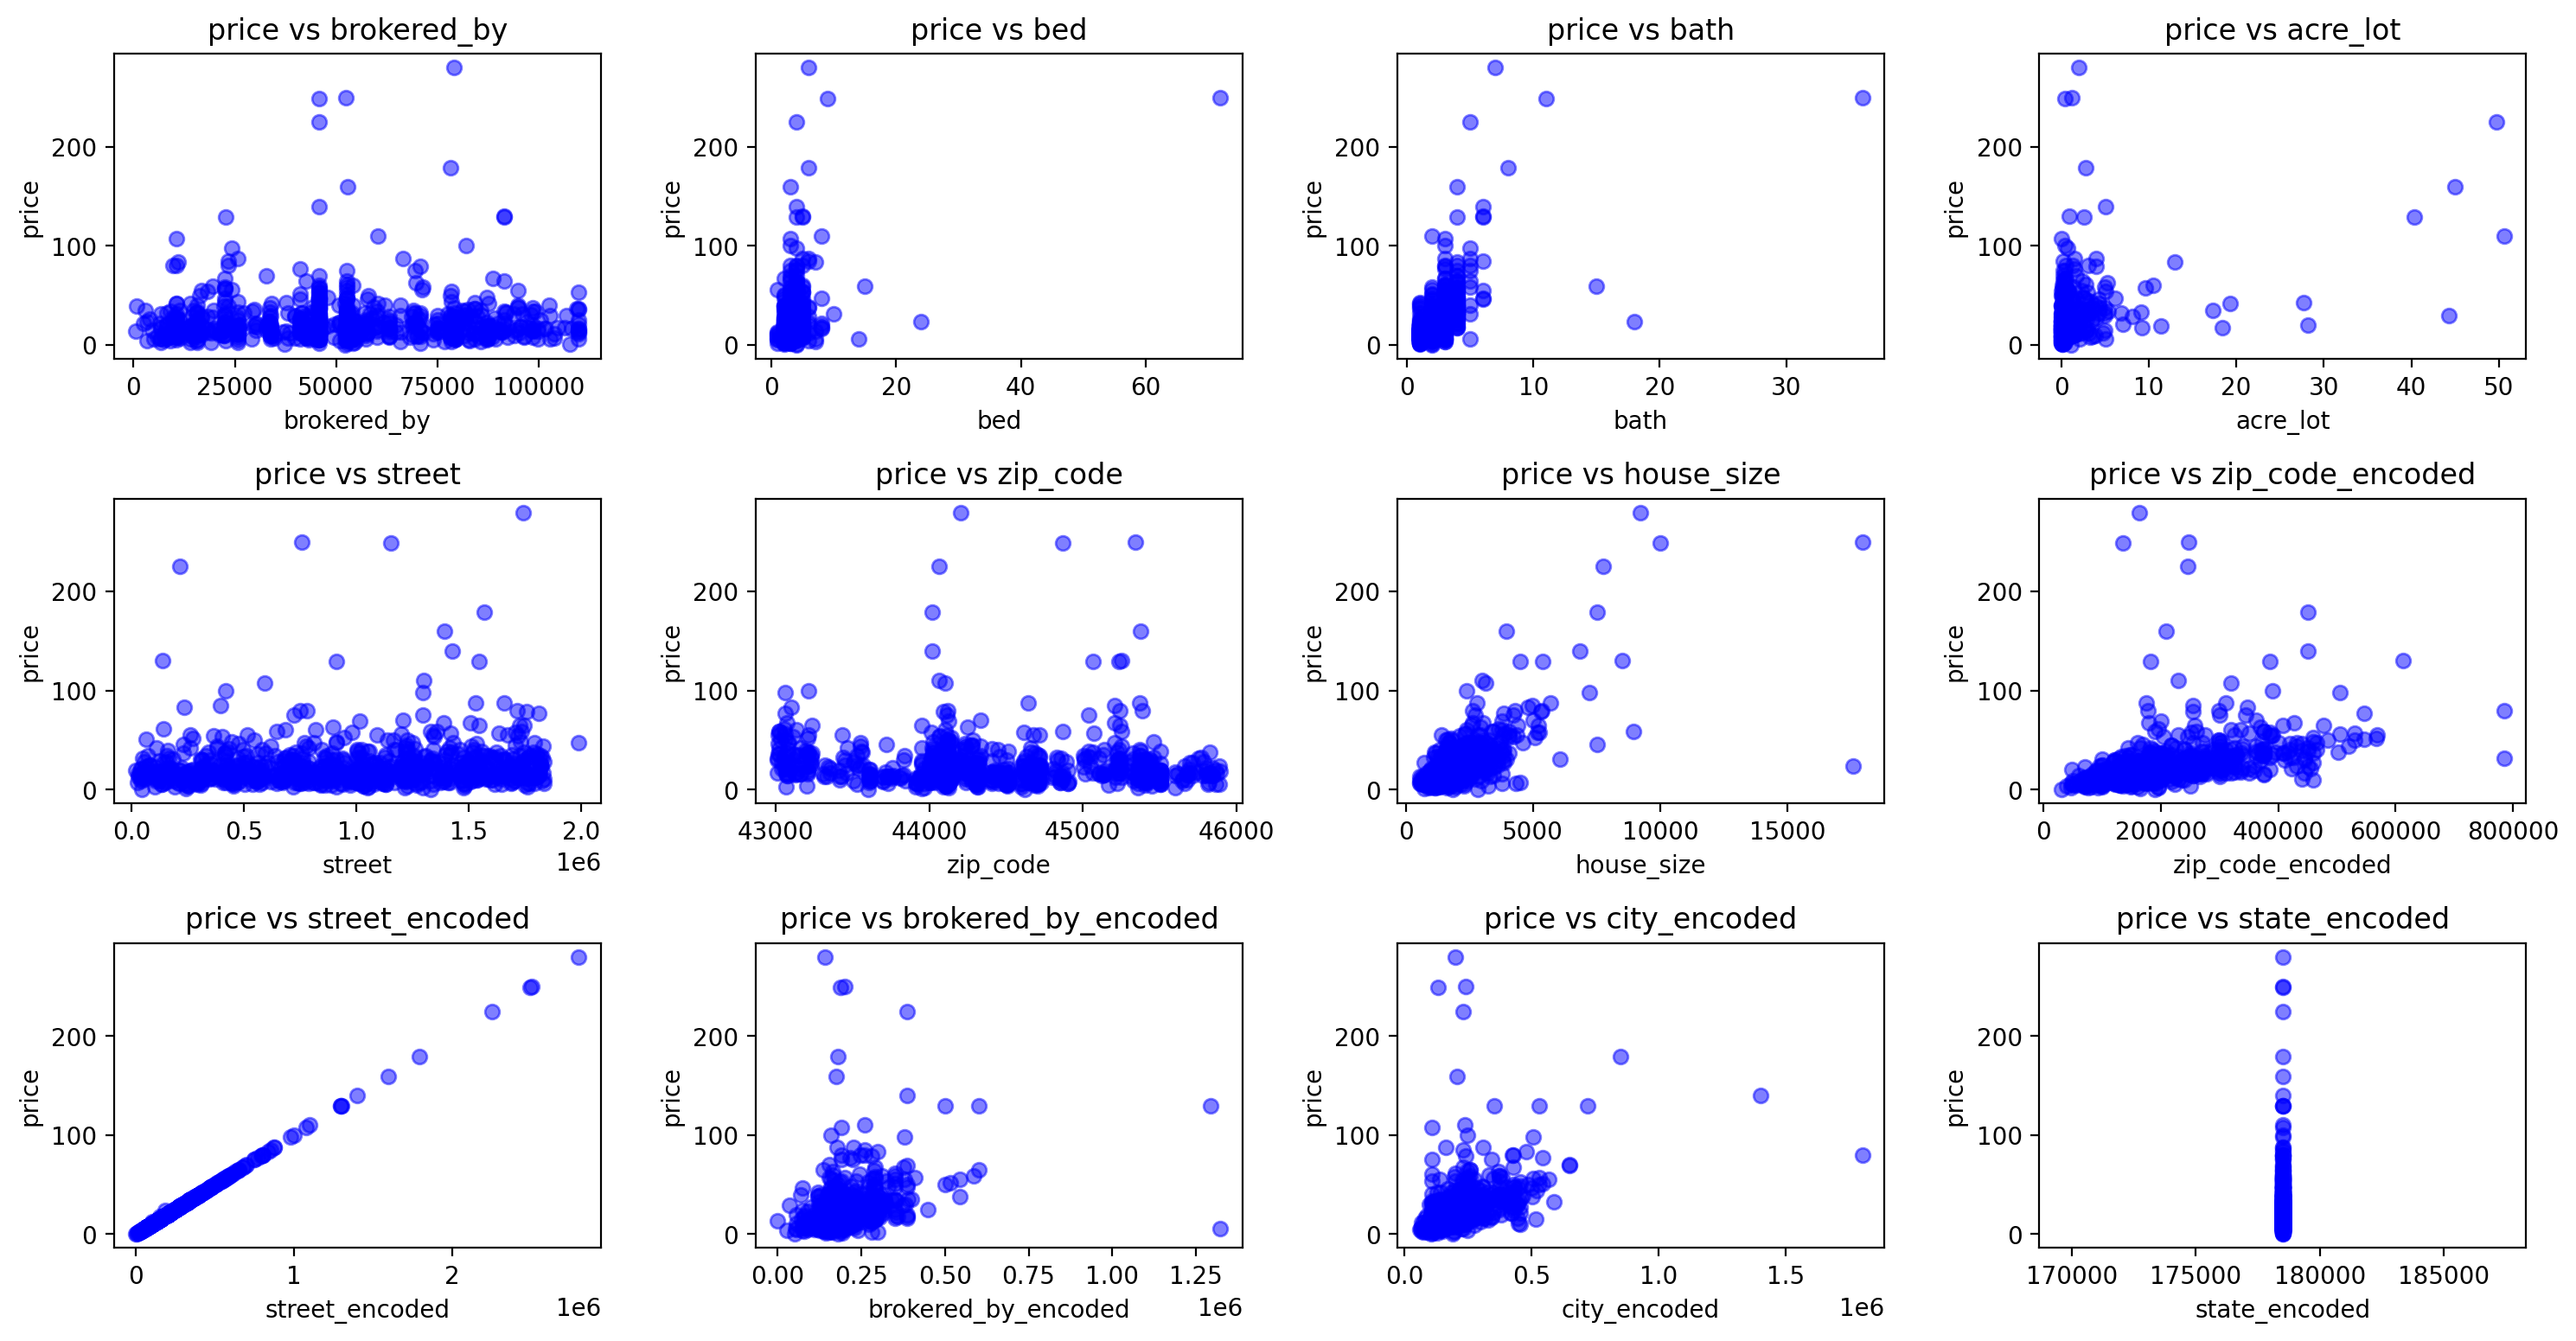

In [61]:
# Create a copy of df
dfvs = df.copy()

# Divide the 'price' column by 10000
dfvs['price'] = dfvs['price'] / 10000

# Drop unwanted columns
dfvs.drop(columns=['status', 'prev_sold_date', 'city', 'state'], inplace=True)

# Print the first 5 rows to verify
print(dfvs.head())

# Define the response variable (target) - not strictly needed if you're just plotting
y_response = dfvs['price']

# Create a list of predictors (exclude 'price')
predictor_cols = [col for col in dfvs.columns if col != 'price']

# Subset the DataFrame to every 50th row (adjust as desired)
dfvs_subset = dfvs.iloc[::50]

# Set figure size
plt.figure(figsize=(15, 10))

# We'll use a grid that can accommodate the number of predictors.
# If you have fewer than 9 predictors, a 3x3 grid will work well.
for i, col in enumerate(predictor_cols):
    plt.subplot(4, 4, i + 1)  # Adjust rows and columns as needed
    plt.scatter(dfvs_subset[col], dfvs_subset['price'], color='blue', alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('price')
    plt.title(f'price vs {col}')

plt.tight_layout()
plt.show()


###Correlation Matrix

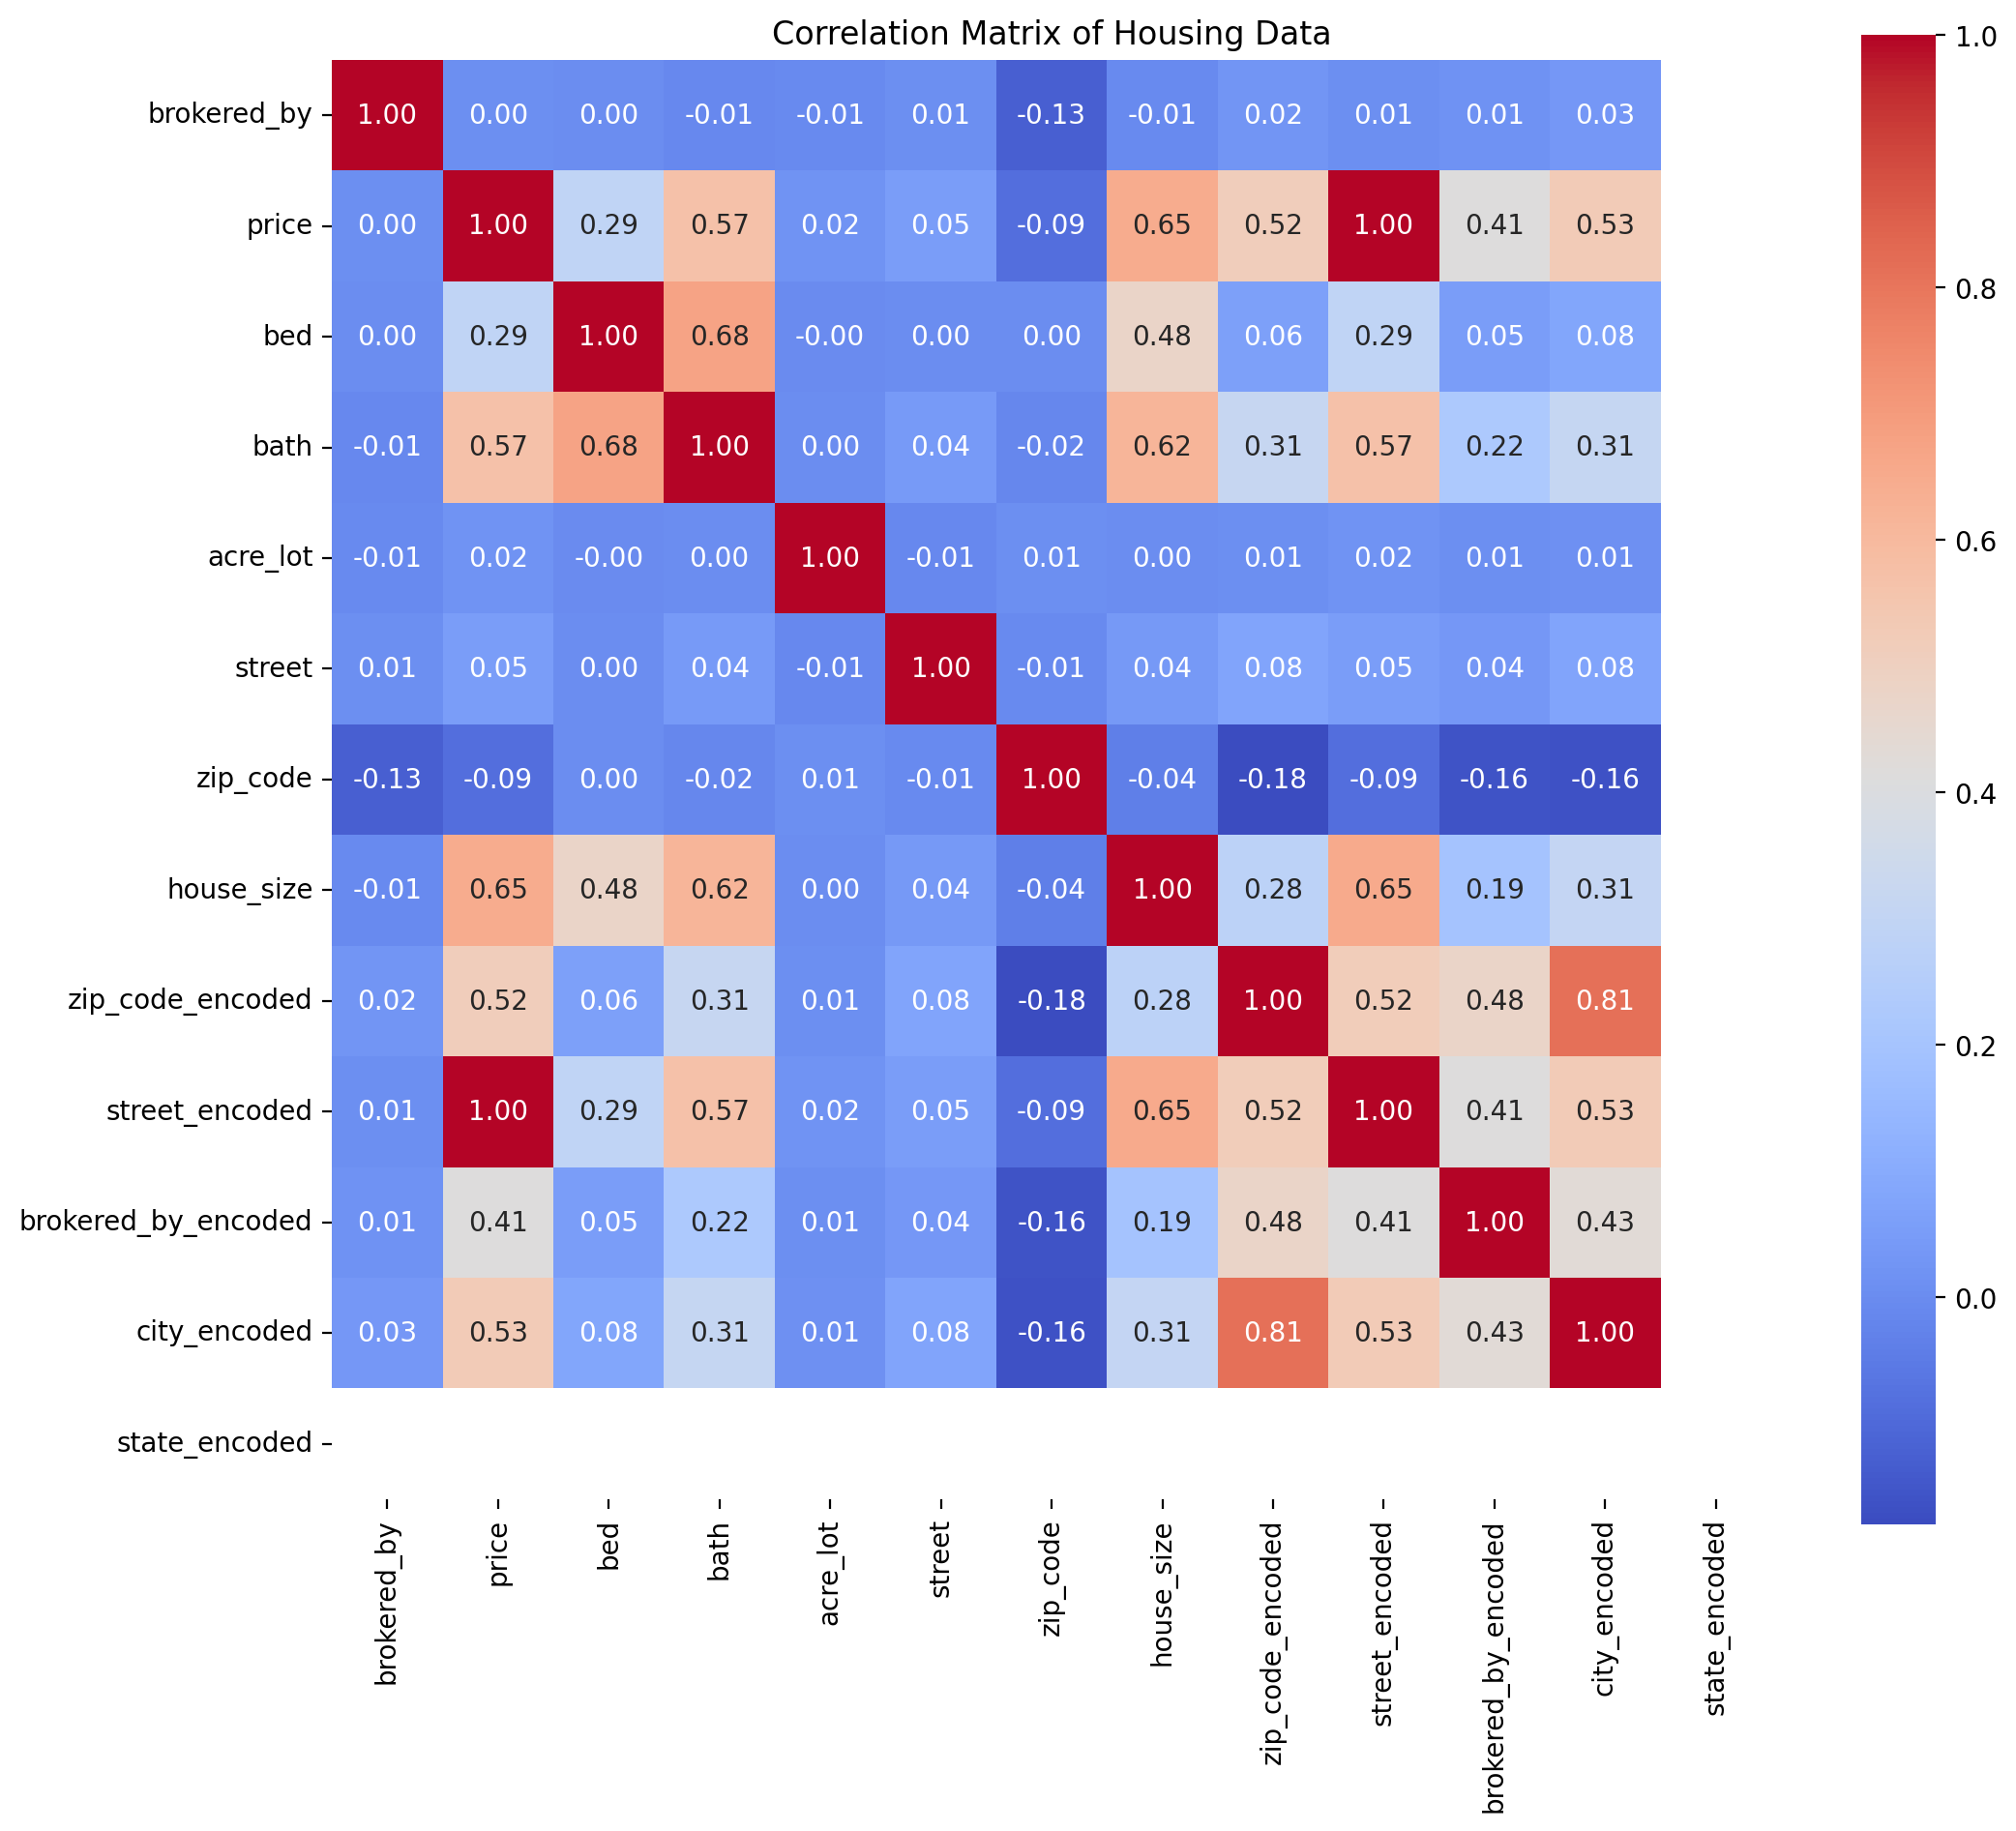

In [62]:
# Compute the correlation matrix
corr_matrix = dfvs.corr()

# Set up the plot
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar=True)

# Add a title
plt.title("Correlation Matrix of Housing Data")

# Show the plot
plt.show()


## Remove Unnecessary Columns (Feature Reduction)
City, Street, Zip-code and are all locations and they are captured in zip-code encoded feature.

Brokered by is just the broker for the deal, probably not predictive.
Street-encoded has too many values that only one property was for sale on a street so the median is the only value and has too much coorelation with price.

In [63]:
##Remove Unnecessary Columns
data.drop(columns=['status', 'state', 'brokered_by', 'city', 'street', 'prev_sold_date', 'zip_code', 'street_encoded', 'city_encoded', 'state_encoded', 'brokered_by_encoded'], inplace=True)

# Handle missing values (fill NaNs with column mean or drop rows)
data = data.dropna() # Drop any NANs


# Display the entire dataset
print(data.describe())
data.shape

#Features - status, price, bed, bath, acre_lot, house_size, zip_code_encoded

              price           bed          bath      acre_lot    house_size  \
count  4.119500e+04  41195.000000  41195.000000  41195.000000  41195.000000   
mean   2.349315e+05      3.303508      2.195631      1.919444   1947.544799   
std    2.319950e+05      1.330950      1.294954     89.965737   1237.602795   
min    1.000000e+00      1.000000      1.000000      0.000000    200.000000   
25%    1.190000e+05      3.000000      1.000000      0.140000   1266.000000   
50%    1.785000e+05      3.000000      2.000000      0.220000   1677.000000   
75%    2.850000e+05      4.000000      3.000000      0.460000   2258.000000   
max    6.900000e+06    102.000000     99.000000  12371.000000  75466.000000   

       zip_code_encoded  
count      4.119500e+04  
mean       2.001281e+05  
std        1.015296e+05  
min        1.000000e+00  
25%        1.299000e+05  
50%        1.715000e+05  
75%        2.499000e+05  
max        1.424500e+06  


(41195, 6)

##Remove 99th Percentile


In [64]:
# Divide the 'price' column by 10000
data['price'] = data['price'] / 10000

percentile_99 = {}
for col in data.columns:
    percentile_99[col] = data[col].quantile(0.99)

mask = (data <= percentile_99)
data = data[mask.all(axis=1)]

print(data.describe())
data.shape



              price           bed          bath      acre_lot    house_size  \
count  39581.000000  39581.000000  39581.000000  39581.000000  39581.000000   
mean      21.248083      3.220459      2.107931      0.631658   1842.576691   
std       14.641736      0.826455      0.935123      1.479573    837.630993   
min        0.000100      1.000000      1.000000      0.000000    200.000000   
25%       11.500000      3.000000      1.000000      0.130000   1252.000000   
50%       17.490000      3.000000      2.000000      0.210000   1647.000000   
75%       27.490000      4.000000      3.000000      0.450000   2192.000000   
max      105.000000      6.000000      6.000000     17.220000   6066.000000   

       zip_code_encoded  
count      39581.000000  
mean      195083.407115  
std        92299.168856  
min            1.000000  
25%       129800.000000  
50%       169900.000000  
75%       242500.000000  
max       530000.000000  


(39581, 6)

##Scatter Plot

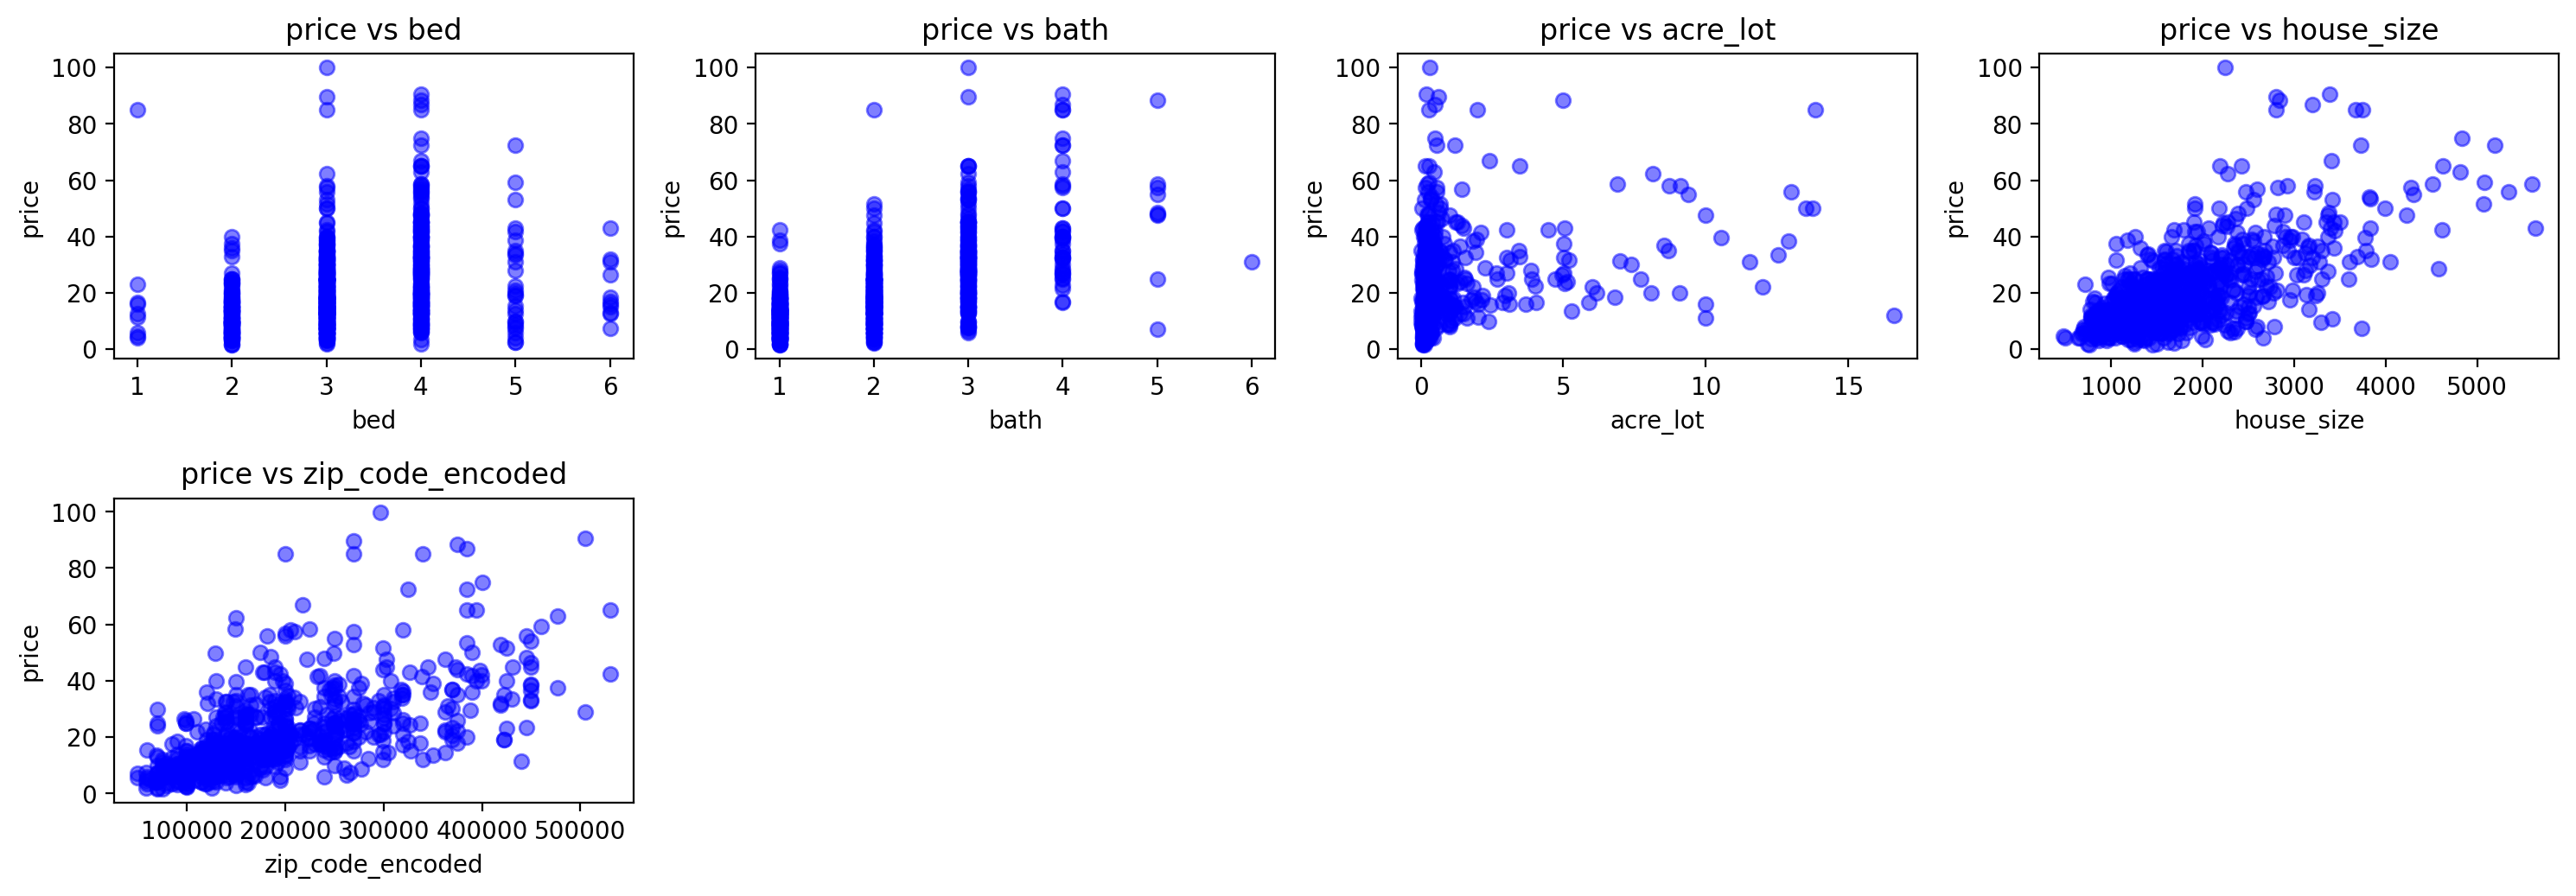

In [80]:
# Creating scatter plots

# Define the response variable (target)
y_response = data['price']

# Create scatter plots for each predictor against the target variable
predictor_cols = [col for col in data.columns if col != 'price']

# Subset the DataFrame to every 50th row (adjust as desired)
data_subset = data.iloc[::50]

plt.figure(figsize=(15, 10))  # Set figure size

for i, col in enumerate(predictor_cols):
    plt.subplot(4, 4, i + 1)
    plt.scatter(data_subset[col], data_subset['price'], color='blue', alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('price')
    plt.title(f'price vs {col}')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


##Split for training and standardizing

In [65]:
# Set the random seed for reproducibility
np.random.seed(934)

# Define X and y
X = data.drop('price', axis=1)  # Features (all columns except 'price')
y = data['price']  # Target variable

total_rows = len(X)
train_size = int(0.8 * total_rows)

# Split the dataset into train and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(X, y, train_size=train_size, random_state=934)

# Check the shapes of the train and validation sets
print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)

# Standardize the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)


print("Means:", np.mean(x_train_scaled, axis=0))
print("Stds:", np.std(x_train_scaled, axis=0))

(31664, 5)
(7917, 5)
(31664,)
(7917,)
Means: [-9.73899530e-17 -1.68188410e-16 -8.97603254e-18  5.07145838e-17
 -1.00082763e-16]
Stds: [1. 1. 1. 1. 1.]


In [66]:
# Check the shapes of the train and validation sets
print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)

x_train.head()

(31664, 5)
(7917, 5)
(31664,)
(7917,)


,bed,bath,acre_lot,house_size,zip_code_encoded
40590,3.0,1.0,0.15,1441.0,149900.0
32508,5.0,3.0,3.74,2375.0,289900.0
17548,4.0,3.0,0.37,3590.0,275000.0
20100,2.0,1.0,0.14,1224.0,144000.0
34681,3.0,1.0,0.18,1368.0,140500.0


#Clustering Algorithms


##k-means


###Elbow Method


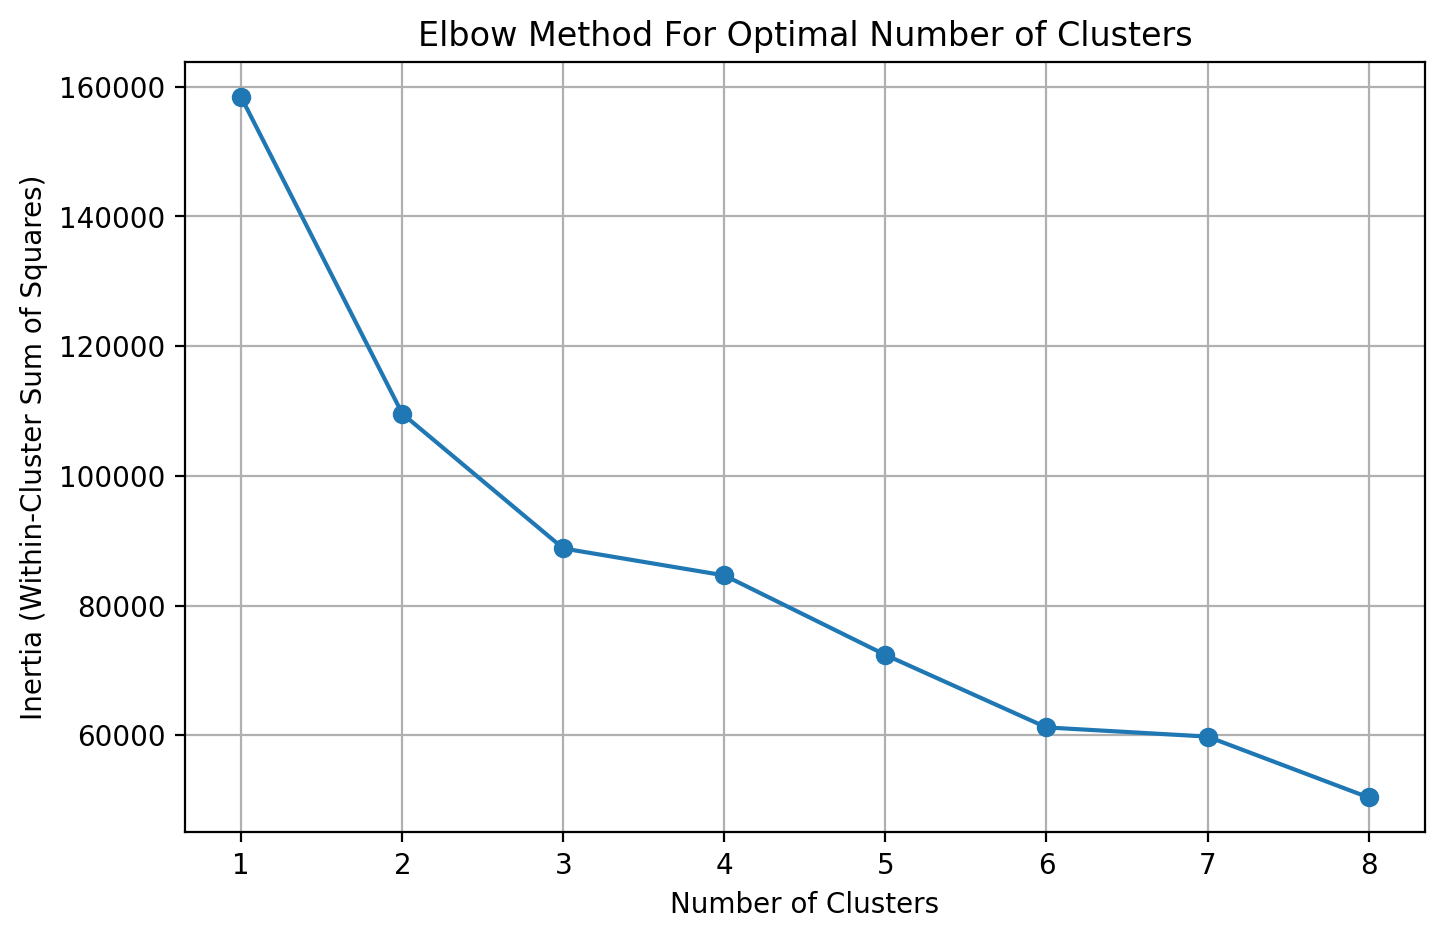

In [82]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Range of clusters to try
cluster_range = range(1, 9)
inertias = []

# Loop over the number of clusters
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=934)
    kmeans.fit(x_train_scaled)  # using your scaled training data
    inertias.append(kmeans.inertia_)  # inertia: sum of squared distances to cluster center

# Plot the elbow method
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertias, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()


###Run and Plot Clusters

Seed 934: Silhouette Score = 0.3747
Seed 42: Silhouette Score = 0.2107
Seed 123: Silhouette Score = 0.3764
Seed 2020: Silhouette Score = 0.2223
Seed 7: Silhouette Score = 0.2107

Best seed is 123 with a silhouette score of 0.3764

Cluster Summary:
              price       
              mean  count
cluster                  
0        34.106072   9156
1        15.065680  21504
2        33.783484   1004

Cluster Centers:
 [[ 0.86372083  1.09207855 -0.0572973   1.06267524  0.68895584]
 [-0.36633282 -0.47361304 -0.19238968 -0.46767877 -0.30384589]
 [ 0.01852108  0.24714258  4.64857127  0.3867768   0.26447659]]


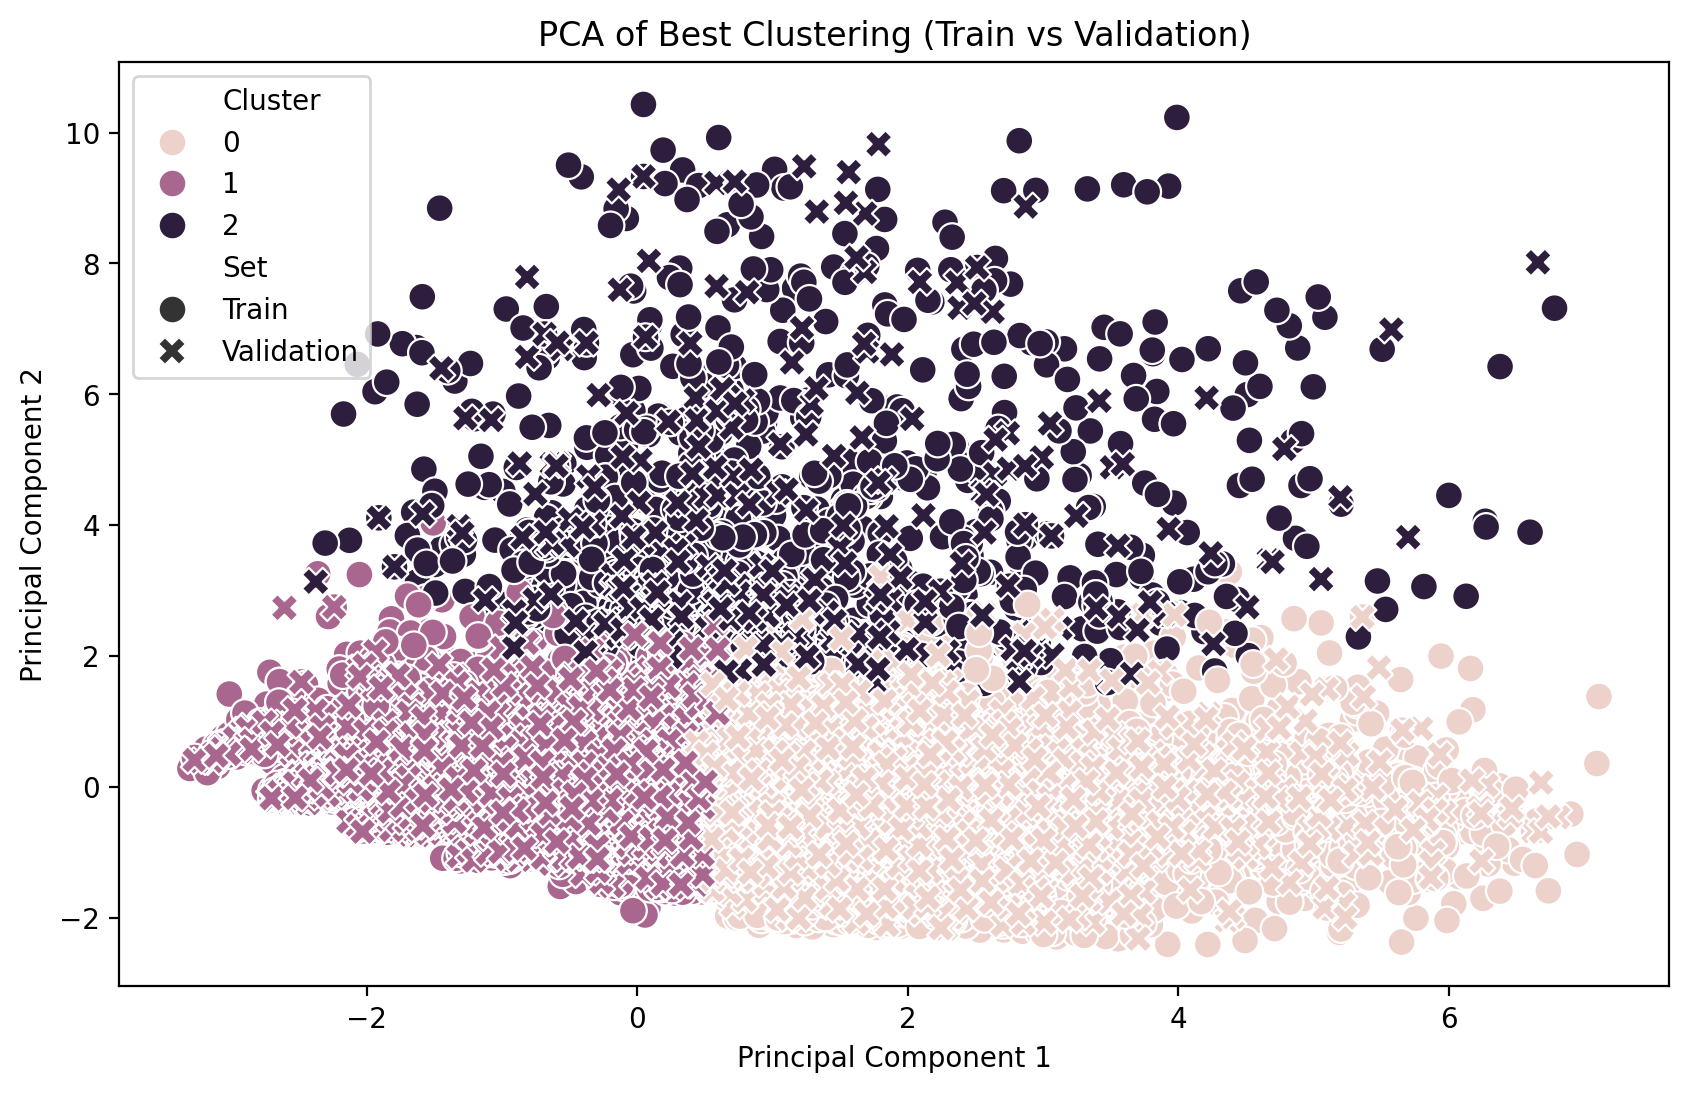

Explained Variance Ratio: [0.47598408 0.2012983 ]


In [83]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Number of clusters
n_clusters = 3

# List of seeds to try
seeds = [934, 42, 123, 2020, 7]

best_seed = None
best_silhouette = -1
best_kmeans = None
best_x_train_clusters = None

# Run k-means for each seed and select the best based on silhouette score
for seed in seeds:
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
    clusters = kmeans.fit_predict(x_train_scaled)

    # Compute silhouette score (note: silhouette_score requires >1 cluster per sample)
    score = silhouette_score(x_train_scaled, clusters)
    print(f"Seed {seed}: Silhouette Score = {score:.4f}")

    if score > best_silhouette:
        best_silhouette = score
        best_seed = seed
        best_kmeans = kmeans
        best_x_train_clusters = clusters

print(f"\nBest seed is {best_seed} with a silhouette score of {best_silhouette:.4f}")

# Use the best k-means model to assign clusters for train and validation sets
# For train set:
x_train_df = pd.DataFrame(x_train_scaled, columns=X.columns, index=x_train.index)
x_train_df['cluster'] = best_x_train_clusters

# Join with y_train using index alignment
train_data = x_train_df.join(y_train, how='inner')

# For validation set, predict using the best model
x_valid_clusters = best_kmeans.predict(x_valid_scaled)
x_valid_df = pd.DataFrame(x_valid_scaled, columns=X.columns, index=x_valid.index)
x_valid_df['cluster'] = x_valid_clusters
valid_data = x_valid_df.join(y_valid, how='inner')

# Quick check of cluster assignments and average prices per cluster
cluster_summary = train_data.groupby('cluster').agg({'price': ['mean', 'count']})
print("\nCluster Summary:\n", cluster_summary)

# Print cluster centers in scaled space
print("\nCluster Centers:\n", best_kmeans.cluster_centers_)

########### PCA for Visualization
# Reduce dimensionality for visualization using PCA
pca = PCA(n_components=2)  # using 2 components for a 2D scatter plot
x_train_pca = pca.fit_transform(x_train_scaled)
x_valid_pca = pca.transform(x_valid_scaled)

# Create a DataFrame for plotting train set
plot_data_train = pd.DataFrame({
    'PC1': x_train_pca[:, 0],
    'PC2': x_train_pca[:, 1],
    'Cluster': best_x_train_clusters,
    'Set': 'Train'
})
# Create a DataFrame for plotting validation set
plot_data_valid = pd.DataFrame({
    'PC1': x_valid_pca[:, 0],
    'PC2': x_valid_pca[:, 1],
    'Cluster': x_valid_clusters,
    'Set': 'Validation'
})
# Combine the data
plot_data = pd.concat([plot_data_train, plot_data_valid])

# Plot clusters with colors for clusters and markers for train/validation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='PC1', y='PC2', hue='Cluster', style='Set', s=100)
plt.title('PCA of Best Clustering (Train vs Validation)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# Print explained variance ratio to see how much info PCA captures
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


In [84]:
print("x_train_scaled shape:", x_train_scaled.shape)
print("y_train shape:", y_train.shape)
print("x_train_df shape:", x_train_df.shape)
print("train_data shape:", train_data.shape)

x_train_scaled shape: (31664, 5)
y_train shape: (31664,)
x_train_df shape: (31664, 6)
train_data shape: (31664, 7)


In [85]:
#Double Checking data frame sizes make sense

print("x_valid_scaled shape:", x_valid_scaled.shape)
print("y_valid shape:", y_valid.shape)
print("x_valid_df shape:", x_valid_df.shape)
print("valid_data shape:", valid_data.shape)

print(valid_data.head())

x_valid_scaled shape: (7917, 5)
y_valid shape: (7917,)
x_valid_df shape: (7917, 6)
valid_data shape: (7917, 7)
           bed      bath  acre_lot  house_size  zip_code_encoded  cluster  \
5184 -0.262225  0.957534 -0.339865   -0.101392          1.955855        0   
209  -1.466792 -1.181096 -0.271768   -0.764660         -1.030705        1   
1164  0.942343 -0.111781 -0.292197   -0.265117         -0.758656        1   
5161 -0.262225 -0.111781 -0.217290   -0.415697          1.141339        1   
5681 -0.262225 -1.181096  0.116385   -0.955872          0.295328        1   

      price  
5184  31.50  
209    0.45  
1164  11.00  
5161  31.50  
5681   9.20  


###Summarize Characteristics of each k-means group

These are being unstandardized so the numbers make sense.

In [70]:
# Group by cluster and summarize key features
cluster_analysis = train_data.groupby('cluster').agg({
    'price': ['mean', 'median'],
    'bed': ['mean', 'median'],
    'bath': ['mean', 'median'],
    'acre_lot': ['mean', 'median'],
    'house_size': ['mean', 'median'],
    'zip_code_encoded': ['mean', 'median']
    #'broker_by_encoded': ['mean', 'median']
})


features = ['bed', 'bath', 'acre_lot', 'house_size', 'zip_code_encoded']
unstandardized_cluster_analysis = cluster_analysis.copy()

for feature in features:
    # Get the column index from x_train
    col_index = list(x_train.columns).index(feature)
    original_mean = scaler.mean_[col_index]
    original_scale = scaler.scale_[col_index]

    unstandardized_cluster_analysis[(feature, 'mean')] = (
        cluster_analysis[(feature, 'mean')] * original_scale + original_mean
    )
    unstandardized_cluster_analysis[(feature, 'median')] = (
        cluster_analysis[(feature, 'median')] * original_scale + original_mean
    )
print("Unstandardized Cluster Characteristics:\n", unstandardized_cluster_analysis)




Unstandardized Cluster Characteristics:
              price              bed             bath          acre_lot         \
              mean median      mean median      mean median       mean median   
cluster                                                                         
0        33.975525  31.00  3.936469    4.0  3.125180    3.0   0.480384   0.30   
1        14.930612  13.99  2.909074    3.0  1.655360    2.0   0.310590   0.17   
2        37.325041  32.90  3.232092    3.0  2.432665    2.0  11.122550  10.41   
3        30.269355  27.50  3.239054    3.0  2.243433    2.0   4.494037   4.60   

          house_size         zip_code_encoded            
                mean  median             mean    median  
cluster                                                  
0        2725.697288  2531.0    257439.069175  249900.0  
1        1442.337213  1400.0    166063.413521  150000.0  
2        2306.237822  2012.0    209113.098854  194950.0  
3        2046.462347  1904.0    226935.4303

###k-means Scatter Plots

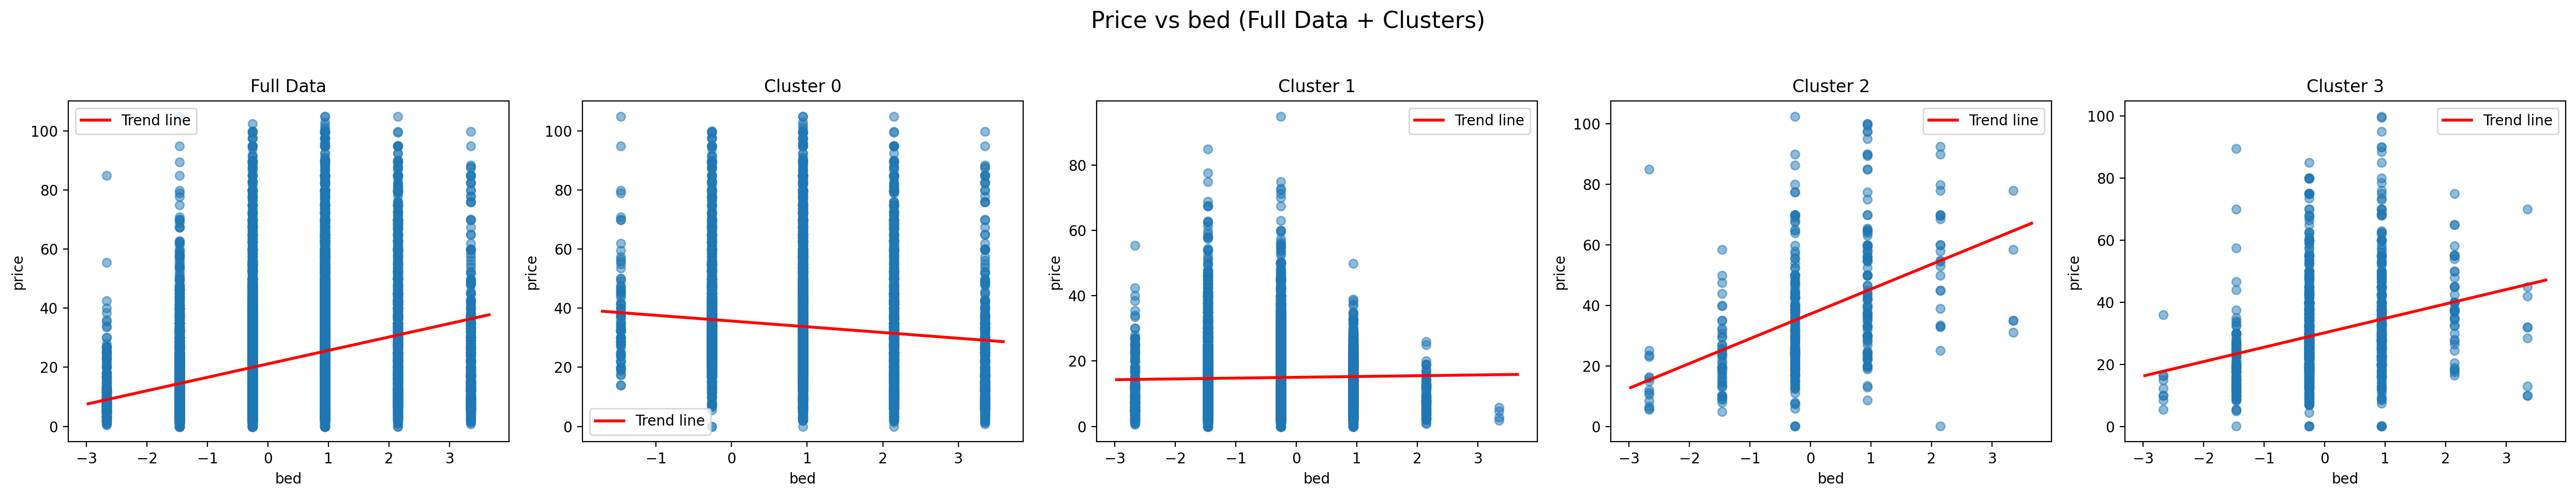

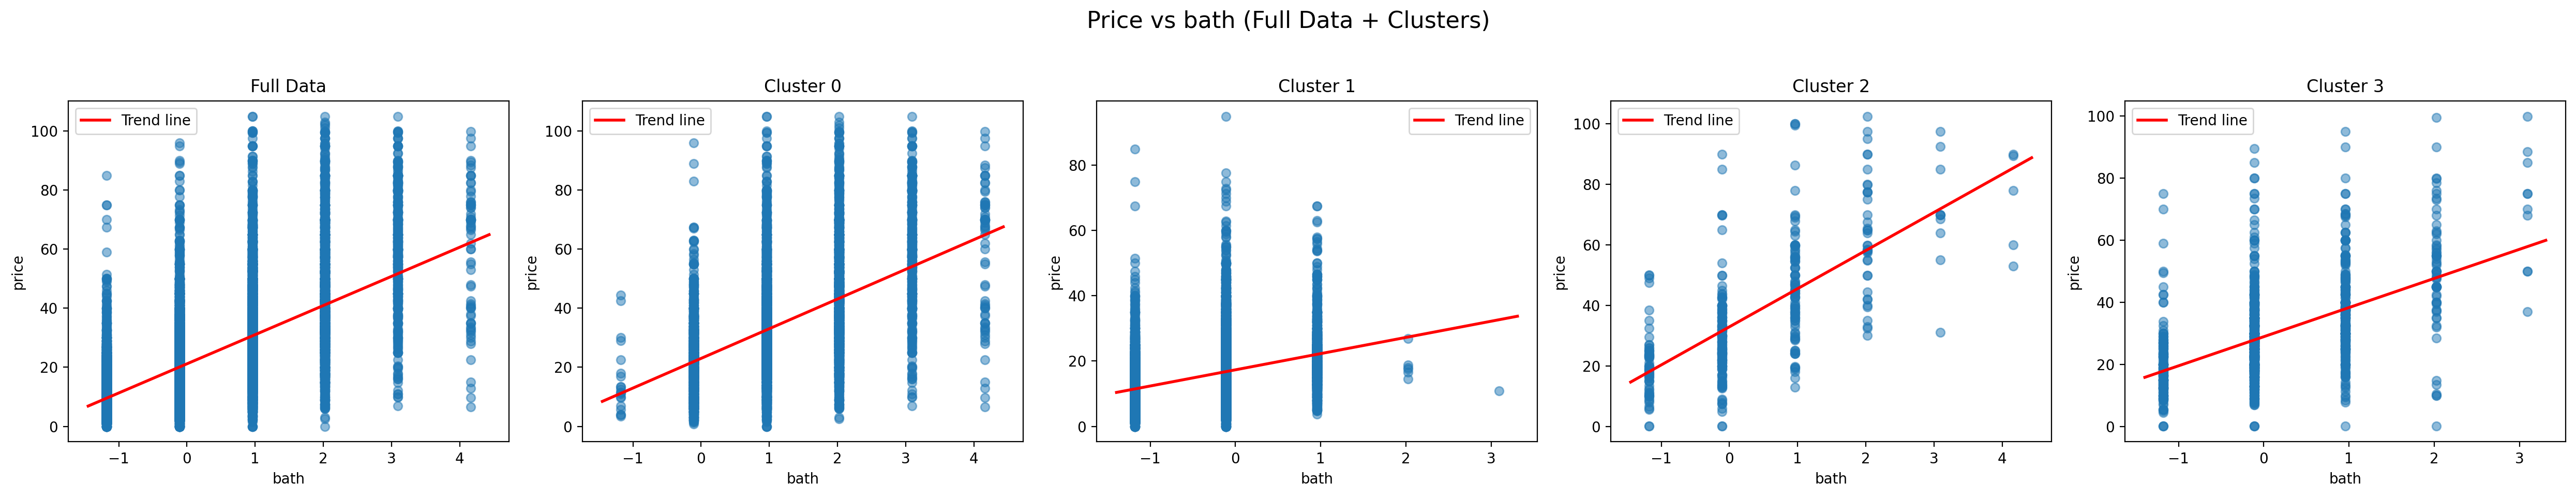

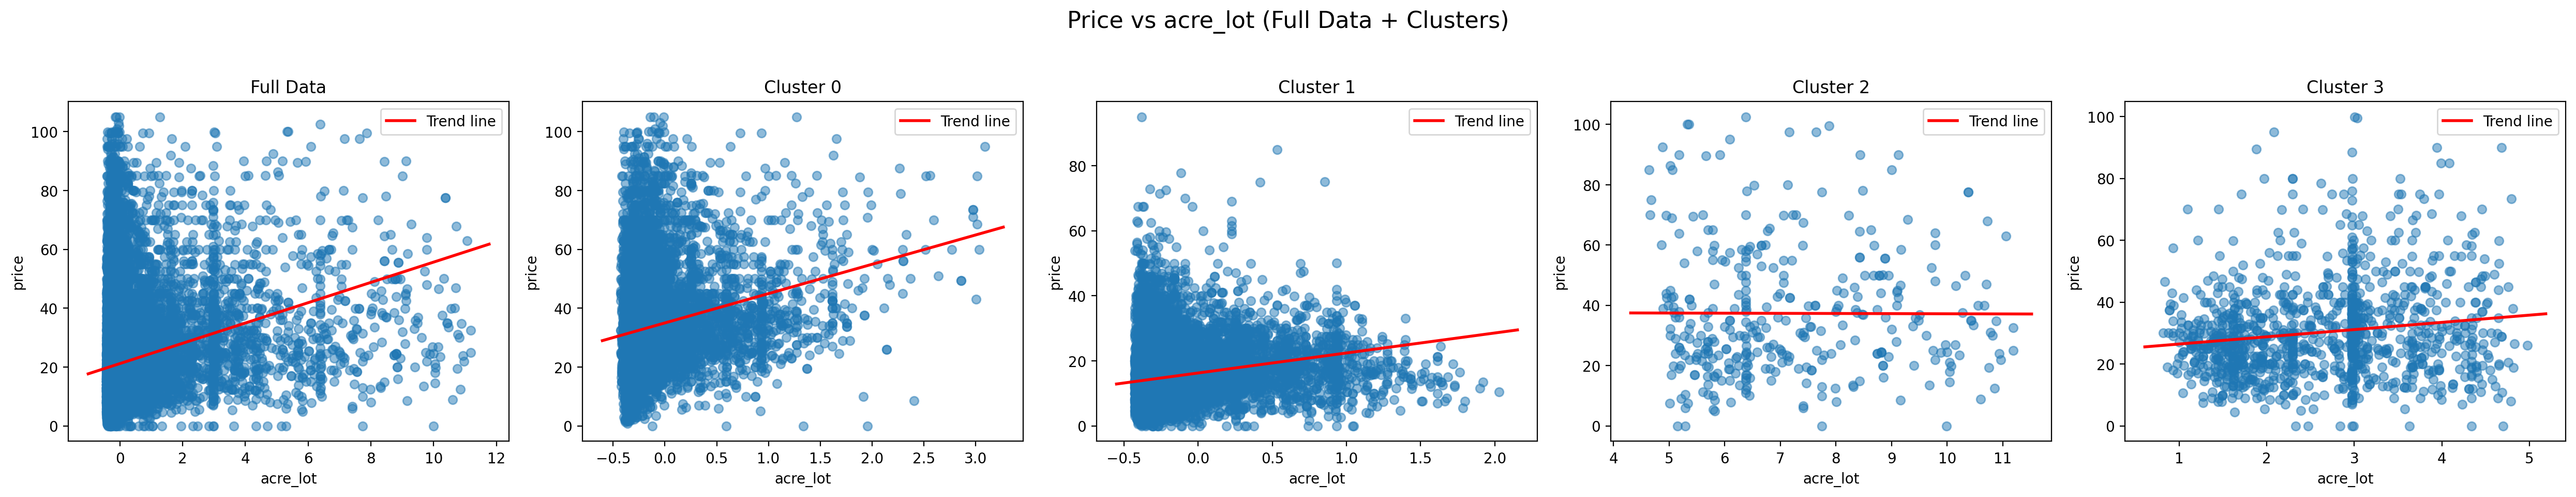

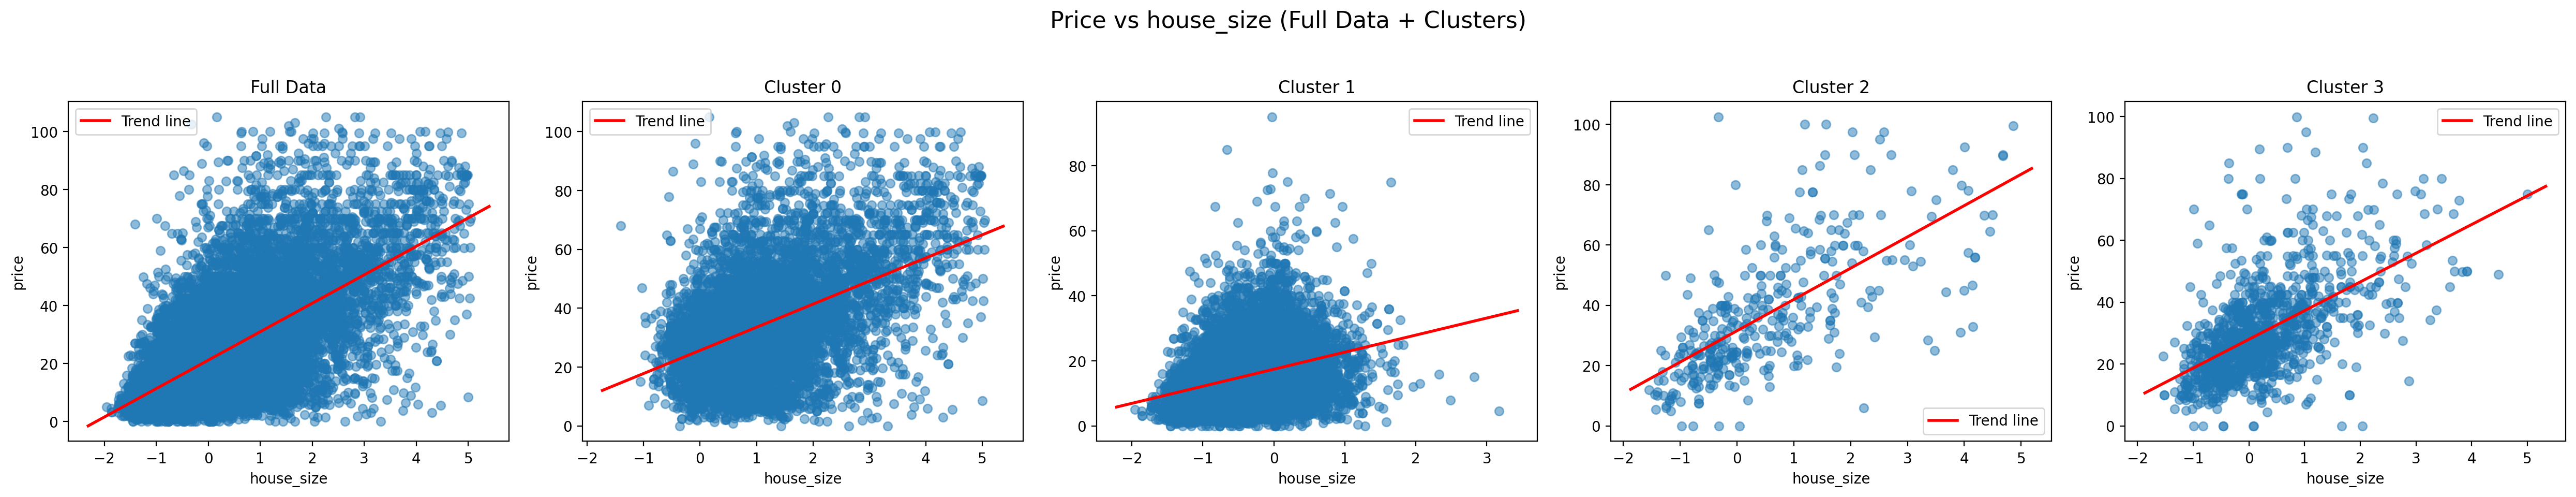

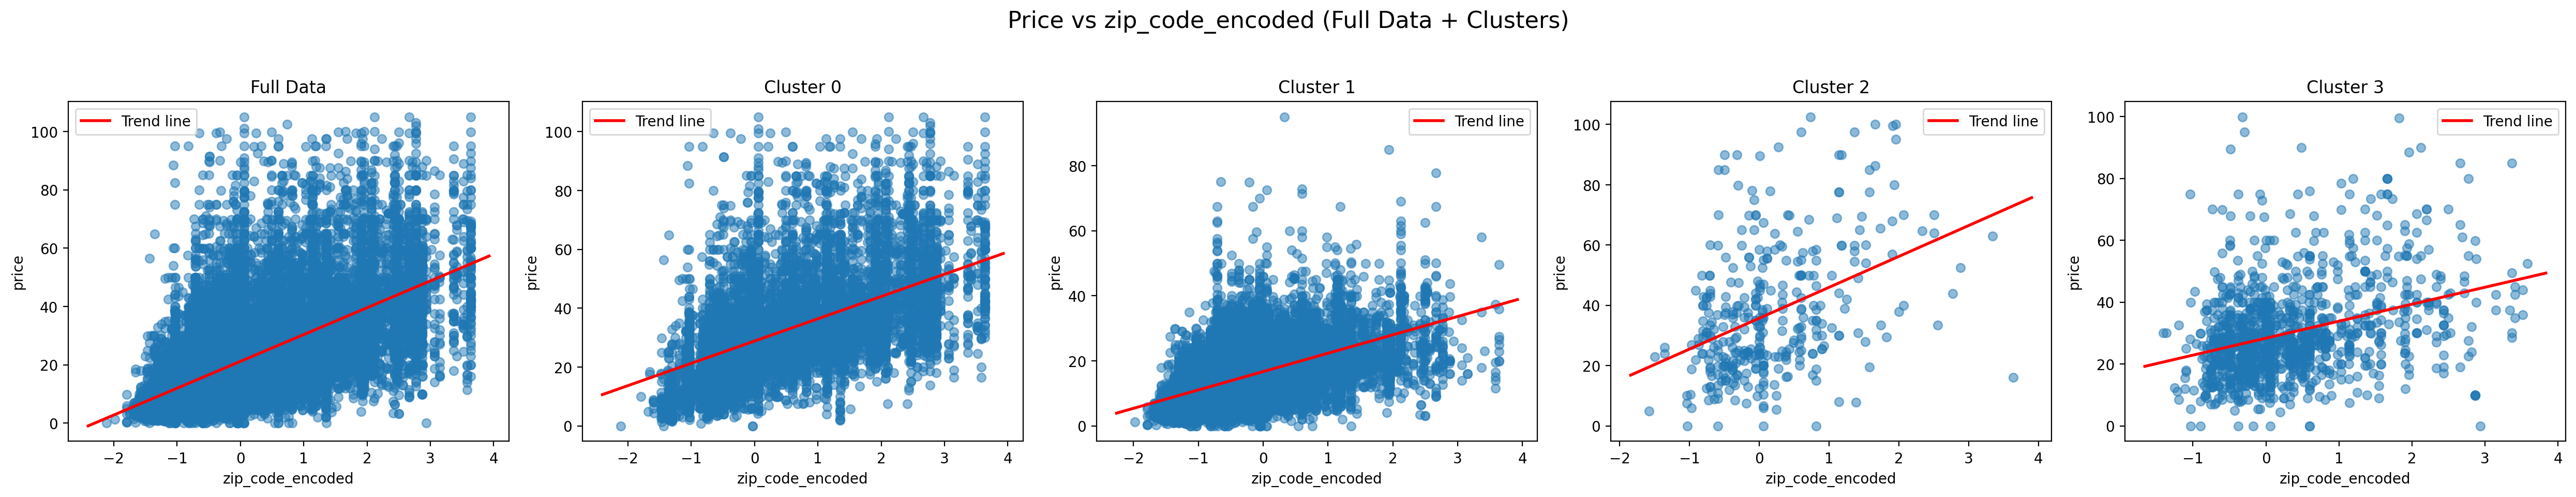

In [71]:


# List of features to plot
features = ['bed', 'bath', 'acre_lot', 'house_size', 'zip_code_encoded']

# Get unique cluster labels (for example, 0, 1, 2, 3)
clusters = sorted(train_data['cluster'].unique())

# Loop through each feature and create a separate figure with subplots:
for feature in features:
    # Total number of subplots: one for full data plus one per cluster
    num_plots = len(clusters) + 1
    plt.figure(figsize=(5 * num_plots, 5))  # Adjust figure size as needed

    # --- Plot for Full Data ---
    ax = plt.subplot(1, num_plots, 1)
    ax.scatter(train_data[feature], train_data['price'], alpha=0.5)

    # Fit and plot a trend line for the full dataset if there's enough data
    if len(train_data) > 1:
        x_full = train_data[feature]
        y_full = train_data['price']
        slope, intercept = np.polyfit(x_full, y_full, 1)
        x_vals = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
        y_vals = intercept + slope * x_vals
        ax.plot(x_vals, y_vals, color='red', linewidth=2, label='Trend line')

    ax.set_title("Full Data")
    ax.set_xlabel(feature)
    ax.set_ylabel("price")
    ax.legend()

    # --- Plots for Each Cluster ---
    for i, cluster in enumerate(clusters):
        ax = plt.subplot(1, num_plots, i + 2)
        cluster_data = train_data[train_data['cluster'] == cluster]
        ax.scatter(cluster_data[feature], cluster_data['price'], alpha=0.5)

        # Fit and plot a trend line for the cluster if there's enough data
        if len(cluster_data) > 1:
            x_cluster = cluster_data[feature]
            y_cluster = cluster_data['price']
            slope, intercept = np.polyfit(x_cluster, y_cluster, 1)
            x_vals = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
            y_vals = intercept + slope * x_vals
            ax.plot(x_vals, y_vals, color='red', linewidth=2, label='Trend line')

        ax.set_title(f"Cluster {cluster}")
        ax.set_xlabel(feature)
        ax.set_ylabel("price")
        ax.legend()

    plt.suptitle(f"Price vs {feature} (Full Data + Clusters)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


##DBSCAN


In [45]:
from sklearn.cluster import DBSCAN
import pandas as pd

# Apply DBSCAN to the scaled training data
dbscan = DBSCAN(eps=.75, min_samples=1000)  # Tweak eps and min_samples as needed
x_train_clusters = dbscan.fit_predict(x_train_scaled)

# Convert scaled x_train back to DataFrame with original column names
x_train_df = pd.DataFrame(x_train_scaled, columns=X.columns, index=x_train.index)
x_train_df['cluster'] = x_train_clusters

# Merge with y_train to include 'price'
train_data = pd.concat([x_train_df, y_train.reset_index(drop=True)], axis=1)

# Predict clusters for validation set (DBSCAN doesn’t “predict” new points, so we fit again or use training labels)
# For simplicity, let’s just check training clusters here

# Quick check of cluster assignments and average prices per cluster
cluster_summary = train_data.groupby('cluster').agg({'price': ['mean', 'count']})
print("Cluster Summary:\n", cluster_summary)

# -1 in clusters means noise (outliers), other numbers are clusters
print(f"Number of clusters (excluding noise): {len(set(x_train_clusters)) - (1 if -1 in x_train_clusters else 0)}")
print(f"Number of noise points: {list(x_train_clusters).count(-1)}")

Cluster Summary:
              price       
              mean  count
cluster                  
-1.0     21.110341  15185
 0.0     20.791934   4479
 1.0     20.998728   2921
 2.0     20.423315   1212
Number of clusters (excluding noise): 3
Number of noise points: 19325


###Visualize DBSCAN

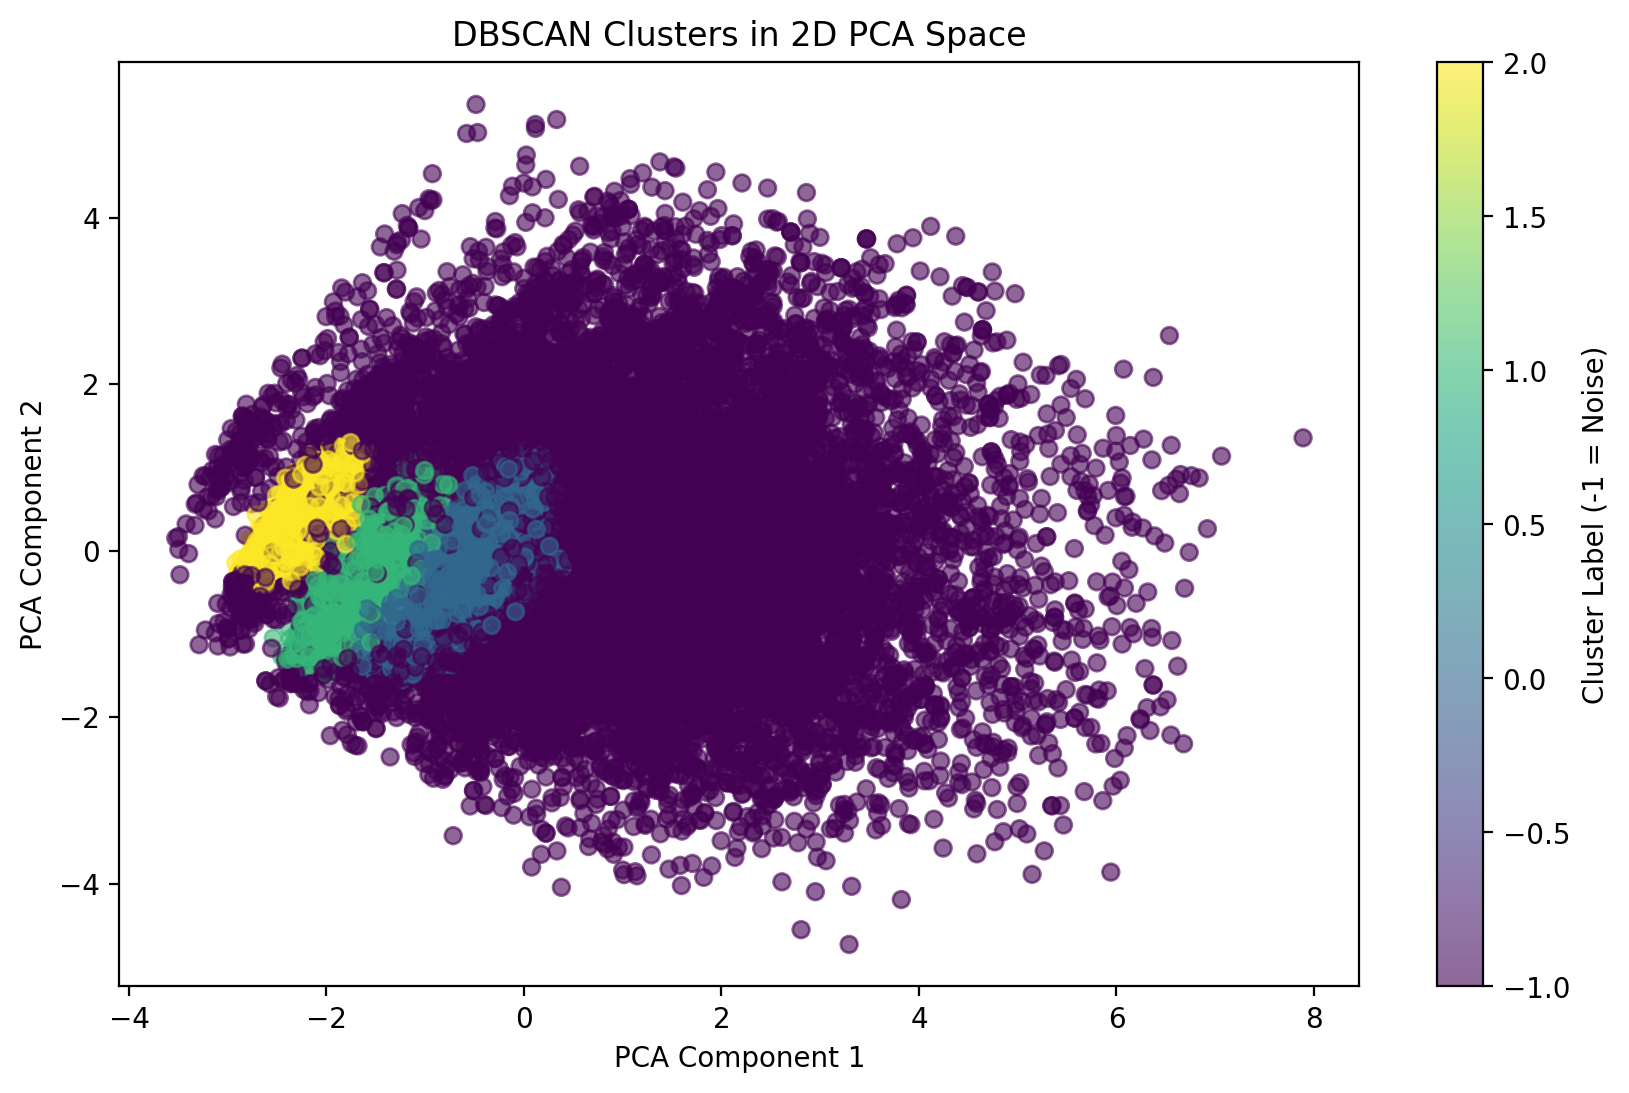

Explained Variance Ratio: [0.41975891 0.20597696]


In [46]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming your DBSCAN code from before
pca = PCA(n_components=2)  # Reduce to 2D
x_train_pca = pca.fit_transform(x_train_scaled)

# Scatter plot with DBSCAN clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_train_pca[:, 0], x_train_pca[:, 1], c=x_train_clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster Label (-1 = Noise)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Clusters in 2D PCA Space')
plt.show()

# Optional: Explained variance ratio to see how much PCA captures
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

#Regression Models



##Regression K-means groups

###Linear Regression (k-means)

In [72]:
# Dictionary to store results for each cluster and the full dataset
cluster_results = {}

# ---------------------------
# Full Data Analysis
# ---------------------------
# Drop the 'cluster' column so that only the original features remain
x_train_full = train_data.drop(columns=['price', 'cluster']).dropna()
y_train_full = train_data.loc[x_train_full.index, 'price']

x_valid_full = valid_data.drop(columns=['price', 'cluster']).dropna()
y_valid_full = valid_data.loc[x_valid_full.index, 'price']

# Initialize and fit linear regression model for the full dataset
lm_full = LinearRegression()
lm_full.fit(x_train_full, y_train_full)
y_pred_full = lm_full.predict(x_valid_full)

# Compute evaluation metrics for the full dataset
mse_full = mean_squared_error(y_valid_full, y_pred_full)
r2_full = r2_score(y_valid_full, y_pred_full)

# Calculate adjusted R²
n_full = len(y_valid_full)
p_full = x_train_full.shape[1]
adjusted_r2_full = 1 - (1 - r2_full) * (n_full - 1) / (n_full - p_full - 1) if n_full > p_full + 1 else None

# Store full dataset results
cluster_results["full"] = {
    'Coefficients': lm_full.coef_,
    'Intercept': lm_full.intercept_,
    'MSE': mse_full,
    'R2': r2_full,
    'Adjusted R2': adjusted_r2_full
}

# Print full dataset results
print("Full Data:")
print("Coefficients:", lm_full.coef_)
print("Intercept:", lm_full.intercept_)
print(f"MSE: {mse_full:.4f}")
print(f"R² Score: {r2_full:.4f}")
print(f"Adjusted R²: {adjusted_r2_full:.4f}\n")

# ---------------------------
# Cluster-Specific Analysis
# ---------------------------
# Iterate over each cluster (assuming clusters are labeled 0, 1, 2, 3)
for cluster_id in range(4):
    # Select data points belonging to the current cluster and drop missing values
    train_subset = train_data[train_data['cluster'] == cluster_id].dropna()
    valid_subset = valid_data[valid_data['cluster'] == cluster_id].dropna()

    # Ensure the cluster has validation data
    if valid_subset.empty:
        print(f"Skipping Cluster {cluster_id}: No validation data available.")
        continue

    # Extract X (features) and y (target)
    x_train_cluster = train_subset.drop(columns=['price', 'cluster'])
    y_train_cluster = train_subset['price']
    x_valid_cluster = valid_subset.drop(columns=['price', 'cluster'])
    y_valid_cluster = valid_subset['price']

    # Check for NaNs after filtering
    if y_valid_cluster.isna().any() or x_valid_cluster.isna().any().any():
        print(f"Skipping Cluster {cluster_id}: NaN values detected after filtering.")
        continue

    # Initialize and fit linear regression model for the current cluster
    lm = LinearRegression()
    lm.fit(x_train_cluster, y_train_cluster)

    # Make predictions on the validation set for the cluster
    y_pred_cluster = lm.predict(x_valid_cluster)

    # Compute evaluation metrics for the current cluster
    mse = mean_squared_error(y_valid_cluster, y_pred_cluster)
    r2 = r2_score(y_valid_cluster, y_pred_cluster)

    # Calculate adjusted R²
    n = len(y_valid_cluster)
    p = x_train_cluster.shape[1]
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else None

    # Store the results for the current cluster
    cluster_results[cluster_id] = {
        'Coefficients': lm.coef_,
        'Intercept': lm.intercept_,
        'MSE': mse,
        'R2': r2,
        'Adjusted R2': adjusted_r2
    }

    # Print the results for the current cluster
    print(f"Cluster {cluster_id}:")
    print("Coefficients:", lm.coef_)
    print("Intercept:", lm.intercept_)
    print(f"MSE: {mse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Adjusted R²: {adjusted_r2:.4f}\n")


Full Data:
Coefficients: [-0.96370143  4.12185432  1.76877508  5.21372452  5.81080253]
Intercept: 21.164925022107127
MSE: 67.8699
R² Score: 0.6955
Adjusted R²: 0.6953

Cluster 0:
Coefficients: [-1.41062307  5.77125747  2.96992627  5.3220981   6.5621124 ]
Intercept: 19.101012063013854
MSE: 125.0304
R² Score: 0.5529
Adjusted R²: 0.5520

Cluster 1:
Coefficients: [-0.18719935  2.94180245  3.57666433  3.58102491  5.12681056]
Intercept: 20.351254800163005
MSE: 32.0122
R² Score: 0.4776
Adjusted R²: 0.4771

Cluster 2:
Coefficients: [-0.25554981  7.20499743  0.0886234   5.69392207  6.73153961]
Intercept: 29.94856898333358
MSE: 265.4511
R² Score: 0.4356
Adjusted R²: 0.4065

Cluster 3:
Coefficients: [0.02438883 5.0754554  1.70519744 5.84668791 4.90551109]
Intercept: 21.87158343736263
MSE: 112.6488
R² Score: 0.5230
Adjusted R²: 0.5148



### Spline Regression (k-means)


In [73]:
# ---------------------------
# Spline Regression for Full Dataset
# ---------------------------
# Prepare training and validation features/target by dropping 'cluster' and 'price'
X_train_full = train_data.drop(columns=['cluster', 'price'])
y_train_full = train_data['price']

X_valid_full = valid_data.drop(columns=['cluster', 'price'])
y_valid_full = valid_data['price']

# Create and fit the spline regression pipeline for the full dataset
spline_model_full = make_pipeline(
    SplineTransformer(degree=3, n_knots=5, include_bias=False),
    LinearRegression()
)

spline_model_full.fit(X_train_full, y_train_full)
y_pred_full = spline_model_full.predict(X_valid_full)

# Evaluate performance for the full dataset
mse_full = mean_squared_error(y_valid_full, y_pred_full)
r2_full = r2_score(y_valid_full, y_pred_full)

# Store and print results for the full dataset
models = {}    # Dictionary to store models
results = {}   # Dictionary to store evaluation metrics

models['full'] = spline_model_full
results['full'] = {'mse': mse_full, 'r2': r2_full}

print("\nFull Data - Spline Model Performance:")
print("Mean Squared Error:", mse_full)
print("R^2 Score:", r2_full)

# ---------------------------
# Spline Regression for Each Cluster
# ---------------------------
# Iterate through each cluster
for cluster in sorted(train_data['cluster'].unique()):
    # Filter data for the current cluster
    train_cluster = train_data[train_data['cluster'] == cluster]
    valid_cluster = valid_data[valid_data['cluster'] == cluster]

    # Prepare training features and target.
    # Drop the cluster column and target column ('price') from features.
    X_train_cluster = train_cluster.drop(columns=['cluster', 'price'])
    y_train_cluster = train_cluster['price']

    X_valid_cluster = valid_cluster.drop(columns=['cluster', 'price'])
    y_valid_cluster = valid_cluster['price']

    # Create a spline regression pipeline (cubic splines with 5 knots)
    spline_model = make_pipeline(
        SplineTransformer(degree=3, n_knots=5, include_bias=False),
        LinearRegression()
    )

    # Fit the model on the cluster-specific training data
    spline_model.fit(X_train_cluster, y_train_cluster)

    # Predict target values on the validation set for the cluster
    y_pred_cluster = spline_model.predict(X_valid_cluster)

    # Evaluate the performance for the current cluster
    mse = mean_squared_error(y_valid_cluster, y_pred_cluster)
    r2 = r2_score(y_valid_cluster, y_pred_cluster)

    # Save the model and its evaluation results
    models[cluster] = spline_model
    results[cluster] = {'mse': mse, 'r2': r2}

    # Print the results for the current cluster
    print(f"\nCluster {cluster} - Spline Model Performance:")
    print("Mean Squared Error:", mse)
    print("R^2 Score:", r2)



Full Data - Spline Model Performance:
Mean Squared Error: 65.18918719761591
R^2 Score: 0.7075258818982522

Cluster 0 - Spline Model Performance:
Mean Squared Error: 122.39112136861192
R^2 Score: 0.5623816842737261

Cluster 1 - Spline Model Performance:
Mean Squared Error: 30.80674340136577
R^2 Score: 0.4973033093408077

Cluster 2 - Spline Model Performance:
Mean Squared Error: 261.4520837964667
R^2 Score: 0.4440808449974364

Cluster 3 - Spline Model Performance:
Mean Squared Error: 125.59105430343669
R^2 Score: 0.4681952819827333


###XGBoost


In [74]:
# Define a list of learning rates to test
learning_rates = [0.001, 0.01, 0.1, 0.3, 0.5, 1]

# Set up 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=934)

# Dictionary to store the best result (highest average R²) for each cluster and full dataset
best_results = {}

def evaluate_model(X, y, lr):
    # Initialize the XGBoost regressor with the given learning rate
    xgb_model = XGBRegressor(learning_rate=lr, n_estimators=100, random_state=42)
    # Compute cross-validated R² scores
    r2_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='r2')
    # Compute cross-validated negative MSE scores (we take the negative later to get MSE)
    mse_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='neg_mean_squared_error')
    avg_r2 = np.mean(r2_scores)
    avg_mse = -np.mean(mse_scores)  # Convert to positive MSE
    return avg_r2, avg_mse

# ---------------------------
# Evaluate on Full Dataset
# ---------------------------
# Prepare features and target from the full training data (drop 'cluster' and 'price')
X_train_full = train_data.drop(columns=['cluster', 'price'])
y_train_full = train_data['price']

best_r2 = -np.inf
best_lr = None
best_mse = None

print("Evaluating Full Dataset:")
for lr in learning_rates:
    avg_r2, avg_mse = evaluate_model(X_train_full, y_train_full, lr)
    print(f"Learning Rate: {lr} -> Average CV R²: {avg_r2:.4f}, Average CV MSE: {avg_mse:.4f}")
    if avg_r2 > best_r2:
        best_r2 = avg_r2
        best_mse = avg_mse
        best_lr = lr

best_results['full'] = {'learning_rate': best_lr, 'r2': best_r2, 'mse': best_mse}

# ---------------------------
# Evaluate for Each Cluster
# ---------------------------
for cluster in sorted(train_data['cluster'].unique()):
    # Filter cluster-specific training data
    train_cluster = train_data[train_data['cluster'] == cluster]
    X_train_cluster = train_cluster.drop(columns=['cluster', 'price'])
    y_train_cluster = train_cluster['price']

    best_r2 = -np.inf
    best_lr = None
    best_mse = None

    print(f"\nEvaluating Cluster {cluster}:")
    for lr in learning_rates:
        avg_r2, avg_mse = evaluate_model(X_train_cluster, y_train_cluster, lr)
        print(f"Learning Rate: {lr} -> Average CV R²: {avg_r2:.4f}, Average CV MSE: {avg_mse:.4f}")
        if avg_r2 > best_r2:
            best_r2 = avg_r2
            best_mse = avg_mse
            best_lr = lr
    best_results[cluster] = {'learning_rate': best_lr, 'r2': best_r2, 'mse': best_mse}

# ---------------------------
# Display the Best Results
# ---------------------------
print("\nBest Results:")
print(f"Full Dataset: Best Learning Rate: {best_results['full']['learning_rate']}, "
      f"Average CV R²: {best_results['full']['r2']:.4f}, "
      f"Average CV MSE: {best_results['full']['mse']:.4f}")

for cluster in sorted(train_data['cluster'].unique()):
    res = best_results[cluster]
    print(f"Cluster {cluster}: Best Learning Rate: {res['learning_rate']}, "
          f"Average CV R²: {res['r2']:.4f}, "
          f"Average CV MSE: {res['mse']:.4f}")


Evaluating Full Dataset:
Learning Rate: 0.001 -> Average CV R²: 0.1252, Average CV MSE: 185.6136
Learning Rate: 0.01 -> Average CV R²: 0.6160, Average CV MSE: 81.4955
Learning Rate: 0.1 -> Average CV R²: 0.7417, Average CV MSE: 54.8354
Learning Rate: 0.3 -> Average CV R²: 0.7406, Average CV MSE: 55.0524
Learning Rate: 0.5 -> Average CV R²: 0.7226, Average CV MSE: 58.8682
Learning Rate: 1 -> Average CV R²: 0.6592, Average CV MSE: 72.3041

Evaluating Cluster 0:
Learning Rate: 0.001 -> Average CV R²: 0.1040, Average CV MSE: 250.3779
Learning Rate: 0.01 -> Average CV R²: 0.5114, Average CV MSE: 136.6033
Learning Rate: 0.1 -> Average CV R²: 0.6279, Average CV MSE: 103.9254
Learning Rate: 0.3 -> Average CV R²: 0.6202, Average CV MSE: 106.0465
Learning Rate: 0.5 -> Average CV R²: 0.5946, Average CV MSE: 113.2517
Learning Rate: 1 -> Average CV R²: 0.4761, Average CV MSE: 146.1733

Evaluating Cluster 1:
Learning Rate: 0.001 -> Average CV R²: 0.0910, Average CV MSE: 55.0392
Learning Rate: 0.01 -

### LASSO Regression (k-means)

Full Dataset Results:
Full Data, Alpha: 0.001 -> R²: 0.6955, MSE: 67.8703
Full Data, Alpha: 0.01 -> R²: 0.6955, MSE: 67.8745
Full Data, Alpha: 0.1 -> R²: 0.6951, MSE: 67.9661
Full Data, Alpha: 1 -> R²: 0.6801, MSE: 71.2977
Full Data, Alpha: 10 -> R²: -0.0008, MSE: 223.0616
Full Data, Alpha: 100 -> R²: -0.0008, MSE: 223.0616
Full Data, Alpha: 1000 -> R²: -0.0008, MSE: 223.0616
Full Data, Alpha: 10000 -> R²: -0.0008, MSE: 223.0616
Full Data, Alpha: 100000 -> R²: -0.0008, MSE: 223.0616

Cluster 0 Results:
Cluster 0, Alpha: 0.001 -> R²: 0.5529, MSE: 125.0310
Cluster 0, Alpha: 0.01 -> R²: 0.5529, MSE: 125.0372
Cluster 0, Alpha: 0.1 -> R²: 0.5524, MSE: 125.1832
Cluster 0, Alpha: 1 -> R²: 0.5359, MSE: 129.8059
Cluster 0, Alpha: 10 -> R²: 0.0018, MSE: 279.1637
Cluster 0, Alpha: 100 -> R²: -0.0024, MSE: 280.3493
Cluster 0, Alpha: 1000 -> R²: -0.0024, MSE: 280.3493
Cluster 0, Alpha: 10000 -> R²: -0.0024, MSE: 280.3493
Cluster 0, Alpha: 100000 -> R²: -0.0024, MSE: 280.3493

Cluster 1 Results:
Clu

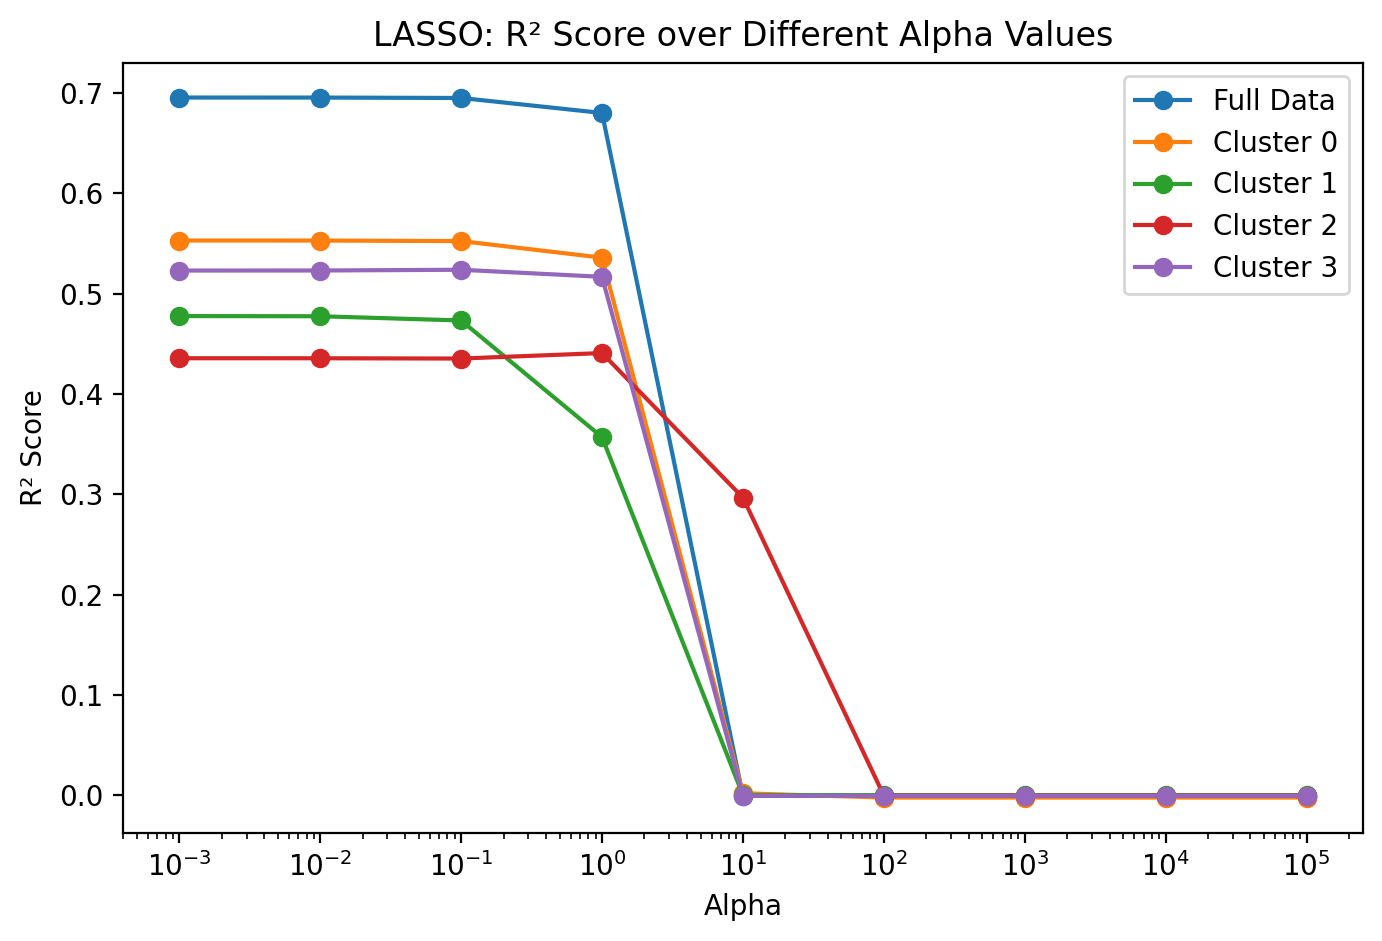

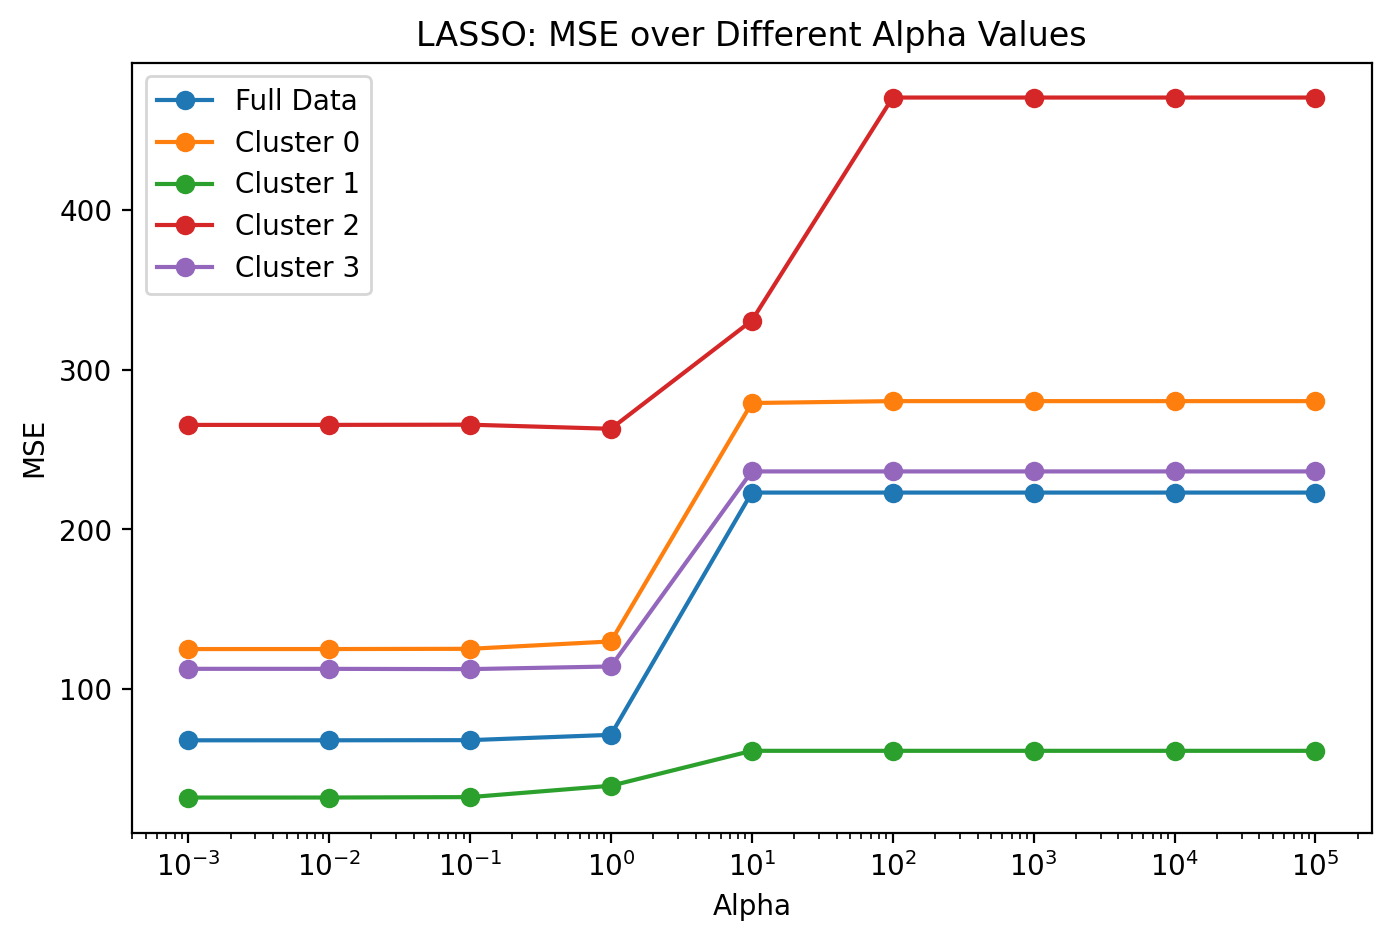


Final Best Results (Highest R²):
Full Data: Best Alpha: 0.001, R²: 0.6955, MSE: 67.8703
Cluster 0: Best Alpha: 0.001, R²: 0.5529, MSE: 125.0310
Cluster 1: Best Alpha: 0.001, R²: 0.4776, MSE: 32.0131
Cluster 2: Best Alpha: 1, R²: 0.4407, MSE: 263.0207
Cluster 3: Best Alpha: 0.1, R²: 0.5238, MSE: 112.4616


In [75]:
# Define the list of alpha values to test
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]

# Dictionaries to store R² and MSE scores for each cluster and the full dataset
cluster_r2 = {}
cluster_mse = {}

# ---------------------------
# Evaluate on Full Dataset
# ---------------------------
# Prepare full training and validation data (drop 'cluster' and 'price' from features)
X_train_full = train_data.drop(columns=['cluster', 'price'])
y_train_full = train_data['price']
X_valid_full = valid_data.drop(columns=['cluster', 'price'])
y_valid_full = valid_data['price']

# Initialize lists for the full dataset
cluster_r2['full'] = []
cluster_mse['full'] = []

print("Full Dataset Results:")
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_full, y_train_full)
    y_pred = lasso.predict(X_valid_full)
    r2 = r2_score(y_valid_full, y_pred)
    mse = mean_squared_error(y_valid_full, y_pred)
    cluster_r2['full'].append(r2)
    cluster_mse['full'].append(mse)
    print(f"Full Data, Alpha: {a} -> R²: {r2:.4f}, MSE: {mse:.4f}")

# ---------------------------
# Evaluate for Each Cluster
# ---------------------------
for cluster in sorted(train_data['cluster'].unique()):
    # Prepare cluster-specific training and validation data
    train_cluster = train_data[train_data['cluster'] == cluster]
    valid_cluster = valid_data[valid_data['cluster'] == cluster]

    # Drop the 'cluster' column and target ('price') from features
    X_train_cluster = train_cluster.drop(columns=['cluster', 'price'])
    y_train_cluster = train_cluster['price']
    X_valid_cluster = valid_cluster.drop(columns=['cluster', 'price'])
    y_valid_cluster = valid_cluster['price']

    # Initialize lists to store scores for the current cluster
    cluster_r2[cluster] = []
    cluster_mse[cluster] = []

    print(f"\nCluster {cluster} Results:")
    for a in alphas:
        lasso = Lasso(alpha=a, max_iter=10000)
        lasso.fit(X_train_cluster, y_train_cluster)
        y_pred = lasso.predict(X_valid_cluster)
        r2 = r2_score(y_valid_cluster, y_pred)
        mse = mean_squared_error(y_valid_cluster, y_pred)
        cluster_r2[cluster].append(r2)
        cluster_mse[cluster].append(mse)
        print(f"Cluster {cluster}, Alpha: {a} -> R²: {r2:.4f}, MSE: {mse:.4f}")

# ---------------------------
# Plot R² vs. Alpha for Full Data and Each Cluster
# ---------------------------
plt.figure(figsize=(8, 5))
for key in cluster_r2.keys():
    label = 'Full Data' if key == 'full' else f'Cluster {key}'
    plt.plot(alphas, cluster_r2[key], marker='o', label=label)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('LASSO: R² Score over Different Alpha Values')
plt.legend()
plt.show()

# ---------------------------
# Plot MSE vs. Alpha for Full Data and Each Cluster
# ---------------------------
plt.figure(figsize=(8, 5))
for key in cluster_mse.keys():
    label = 'Full Data' if key == 'full' else f'Cluster {key}'
    plt.plot(alphas, cluster_mse[key], marker='o', label=label)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('LASSO: MSE over Different Alpha Values')
plt.legend()
plt.show()

# ---------------------------
# Print Final Best Results (Highest R²) for Each Group
# ---------------------------
print("\nFinal Best Results (Highest R²):")
for key in cluster_r2.keys():
    # Find index of maximum R² for this group
    best_idx = np.argmax(cluster_r2[key])
    best_alpha = alphas[best_idx]
    best_r2 = cluster_r2[key][best_idx]
    best_mse = cluster_mse[key][best_idx]
    label = 'Full Data' if key == 'full' else f'Cluster {key}'
    print(f"{label}: Best Alpha: {best_alpha}, R²: {best_r2:.4f}, MSE: {best_mse:.4f}")


###Project Pursuit Regression

In [79]:
# Number of projection terms (random projections to average over)
n_terms = 3
np.random.seed(934)

# -----------------------------------------
# Evaluate on the Full Dataset
# -----------------------------------------
print("Evaluating on Full Dataset:")
# Initialize predictions for full training and validation sets
y_pred_train_full = np.zeros_like(y_train)
y_pred_valid_full = np.zeros_like(y_valid)

# Loop over random projection terms
for _ in range(n_terms):
    # Create a random projection direction (unit vector)
    weights = np.random.randn(x_train_scaled.shape[1])
    weights /= np.linalg.norm(weights)

    # Project the full (scaled) training and validation data
    proj_train = x_train_scaled.dot(weights)
    proj_valid = x_valid_scaled.dot(weights)

    # Generate polynomial features (degree 2) on the projection
    poly = PolynomialFeatures(degree=2)
    proj_train_poly = poly.fit_transform(proj_train.reshape(-1, 1))
    proj_valid_poly = poly.transform(proj_valid.reshape(-1, 1))

    # Fit linear regression on the polynomial features
    lr = LinearRegression()
    lr.fit(proj_train_poly, y_train)

    # Accumulate predictions
    y_pred_train_full += lr.predict(proj_train_poly)
    y_pred_valid_full += lr.predict(proj_valid_poly)

# Optionally average predictions over the random projections
y_pred_valid_full /= n_terms

# Evaluate performance on the full dataset
mse_full = mean_squared_error(y_valid, y_pred_valid_full)
r2_full = r2_score(y_valid, y_pred_valid_full)
n_full = len(y_valid)
p_full = x_valid_scaled.shape[1]
adjusted_r2_full = 1 - (1 - r2_full) * (n_full - 1) / (n_full - p_full - 1)

print(f"Full Dataset Validation MSE: {mse_full:.4f}")
print(f"Full Dataset R² Score: {r2_full:.4f}")
print(f"Full Dataset Adjusted R²: {adjusted_r2_full:.4f}")

# -----------------------------------------
# Evaluate on Each Cluster
# -----------------------------------------
for cluster in sorted(train_data['cluster'].unique()):
    print(f"\nEvaluating on Cluster {cluster}:")

    # Subset training data for this cluster
    train_cluster = train_data[train_data['cluster'] == cluster]
    valid_cluster = valid_data[valid_data['cluster'] == cluster]

    # Get cluster-specific scaled features and targets.
    # Note: Use the same indices on your scaled arrays as in train_data/valid_data.
    x_train_cluster_scaled = x_train_scaled[train_data['cluster'] == cluster]
    y_train_cluster = y_train[train_data['cluster'] == cluster]
    x_valid_cluster_scaled = x_valid_scaled[valid_data['cluster'] == cluster]
    y_valid_cluster = y_valid[valid_data['cluster'] == cluster]

    # Initialize predictions for this cluster
    y_pred_train_cluster = np.zeros_like(y_train_cluster)
    y_pred_valid_cluster = np.zeros_like(y_valid_cluster)

    # Loop over random projection terms for the cluster
    for _ in range(n_terms):
        weights = np.random.randn(x_train_cluster_scaled.shape[1])
        weights /= np.linalg.norm(weights)

        proj_train = x_train_cluster_scaled.dot(weights)
        proj_valid = x_valid_cluster_scaled.dot(weights)

        poly = PolynomialFeatures(degree=2)
        proj_train_poly = poly.fit_transform(proj_train.reshape(-1, 1))
        proj_valid_poly = poly.transform(proj_valid.reshape(-1, 1))

        lr = LinearRegression()
        lr.fit(proj_train_poly, y_train_cluster)

        y_pred_train_cluster += lr.predict(proj_train_poly)
        y_pred_valid_cluster += lr.predict(proj_valid_poly)

    # Average the predictions over the random projections
    y_pred_valid_cluster /= n_terms

    # Evaluate cluster performance
    mse_cluster = mean_squared_error(y_valid_cluster, y_pred_valid_cluster)
    r2_cluster = r2_score(y_valid_cluster, y_pred_valid_cluster)
    n_cluster = len(y_valid_cluster)
    p_cluster = x_valid_cluster_scaled.shape[1]
    adjusted_r2_cluster = 1 - (1 - r2_cluster) * (n_cluster - 1) / (n_cluster - p_cluster - 1) if n_cluster > p_cluster + 1 else None

    print(f"Cluster {cluster} Validation MSE: {mse_cluster:.4f}")
    print(f"Cluster {cluster} R² Score: {r2_cluster:.4f}")
    if adjusted_r2_cluster is not None:
        print(f"Cluster {cluster} Adjusted R²: {adjusted_r2_cluster:.4f}")


Evaluating on Full Dataset:
Full Dataset Validation MSE: 94.7305
Full Dataset R² Score: 0.5750
Full Dataset Adjusted R²: 0.5747

Evaluating on Cluster 0:
Cluster 0 Validation MSE: 174.5397
Cluster 0 R² Score: 0.3759
Cluster 0 Adjusted R²: 0.3746

Evaluating on Cluster 1:
Cluster 1 Validation MSE: 45.9498
Cluster 1 R² Score: 0.2502
Cluster 1 Adjusted R²: 0.2495

Evaluating on Cluster 2:
Cluster 2 Validation MSE: 315.5084
Cluster 2 R² Score: 0.3291
Cluster 2 Adjusted R²: 0.2946

Evaluating on Cluster 3:
Cluster 3 Validation MSE: 193.5265
Cluster 3 R² Score: 0.1805
Cluster 3 Adjusted R²: 0.1664
